# CV Halo FD Jacobian: Scatter-Notebook Statistics — Parameter Derivatives

Finite-difference Jacobians of all 35 per-halo morphological statistics
(from `scatter.ipynb`) and 15 population-level scaling-relation statistics
with respect to all 35 CAMELS cosmological + astrophysical parameters.

Loaded from: `analysis_physics_cache/proj6_cv_fd_scatter_fm_two_head.npz`


## Imports & Configuration

In [6]:
import sys, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')

ROOT      = Path('/mnt/home/mlee1/vdm_bind2')
CACHE_DIR = ROOT / 'analysis_physics_cache'
CV_FD_CACHE = CACHE_DIR / 'proj6_cv_fd_scatter_cube_fm_cube_two_head.npz'
FM_RUN_DIR  = Path('/mnt/home/mlee1/ceph/fm_runs/fm_two_head')
CV_ROOT     = Path('/mnt/home/mlee1/ceph/fm_testsuite/CV')
SIM_SUBPATH = 'snap_090/mass_threshold_1p000e13'
N_PARAMS = 35

# ── CAMELS parameter pretty-print labels ─────────────────────────────────────
PRETTY = {
    0:  r'$\Omega_m$',       1:  r'$\sigma_8$',          2:  r'$A_{\rm SN1}$',
    3:  r'$A_{\rm AGN1}$',   4:  r'$A_{\rm SN2}$',       5:  r'$A_{\rm AGN2}$',
    6:  r'$\Omega_b$',       7:  r'$h$',                   8:  r'$n_s$',
    9:  r'$w_0$',             10: r'$w_a$',                 11: r'$M_\nu$',
    12: r'$\alpha_{\rm SF}$', 13: r'$\beta_{\rm SF}$', 14: r'$\rho_{\rm wind}$',
    15: r'$M_{\rm SNII}$',   16: r'$\eta_w$',             17: r'$E_{\rm SN}$',
    18: r'$\epsilon_r$',     19: r'$M_{\rm seed}$',       20: r'$\alpha_{\rm acc}$',
    21: r'$\beta_{\rm acc}$', 22: r'$M_{\rm fof}$',     23: r'$V_{\rm Bh}$',
    24: r'$\alpha_{w,{\rm SN}}$', 25: r'$\tau_{\rm BH}$', 26: r'$p_{\rm wind}$',
    27: r'$v_{\rm kick}$',   28: r'$\alpha_{w,Z}$',       29: r'$R_{\rm trunc}$',
    30: r'$\beta_{\rm UV}$', 31: r'$\alpha_{\rm UV}$', 32: r'$\beta_{\rm HeII}$',
    33: r'$T_{\rm reion}$',  34: r'$z_{\rm reion}$',
}
PARAM_GROUP = {
    0:'cosmo', 1:'cosmo', 2:'SN',    3:'AGN',   4:'SN',    5:'AGN',
    6:'cosmo', 7:'cosmo', 8:'cosmo', 9:'cosmo', 10:'cosmo',11:'cosmo',
    12:'SN',   13:'SN',   14:'SN',   15:'SN',   16:'SN',   17:'SN',
    18:'AGN',  19:'AGN',  20:'AGN',  21:'AGN',  22:'AGN',  23:'AGN',
    24:'SN',   25:'AGN',  26:'SN',   27:'SN',   28:'SN',   29:'other',
    30:'other',31:'other',32:'other',33:'other', 34:'other',
}
GROUP_COLORS = {'cosmo':'#1E88E5','SN':'#FF8F00','AGN':'#E53935','other':'#757575'}

# ── Per-halo and population observable keys ───────────────────────────────────
PER_HALO_KEYS = [
    "M_dm","M_gas","M_star","M_bar",
    "f_bar","f_gas","f_star",
    "q_dm_R","q_gas_R","q_star_R",
    "q_dm_h","q_gas_h","q_star_h",
    "e1_dm","e1_gas","e1_star","e2_dm","e2_gas","e2_star",
    "conc_dm","conc_gas","conc_star",
    "rhalf_dm","rhalf_gas","rhalf_star",
    "cent4_dm","cent4_gas","cent4_star",
    "peak_dm","peak_gas","peak_star",
    "dtheta_dg","dtheta_ds","dtheta_gs",
    "dq_dm",
]
POP_KEYS = [
    "alpha_MgMs","beta_MgMs","sigma_MgMs",
    "alpha_MdMs","beta_MdMs","sigma_MdMs",
    "alpha_SHMR", "beta_SHMR", "sigma_SHMR",
    "alpha_GasFr","beta_GasFr","sigma_GasFr",
    "alpha_BarFr","beta_BarFr","sigma_BarFr",
]
KEY_GROUPS = {
    'masses':    ["M_dm","M_gas","M_star","M_bar"],
    'fractions': ["f_bar","f_gas","f_star"],
    'q_R':       ["q_dm_R","q_gas_R","q_star_R"],
    'q_h':       ["q_dm_h","q_gas_h","q_star_h"],
    'ellip':     ["e1_dm","e1_gas","e1_star","e2_dm","e2_gas","e2_star"],
    'conc_rhalf':["conc_dm","conc_gas","conc_star","rhalf_dm","rhalf_gas","rhalf_star"],
    'central':   ["cent4_dm","cent4_gas","cent4_star","peak_dm","peak_gas","peak_star"],
    'misalign':  ["dtheta_dg","dtheta_ds","dtheta_gs","dq_dm"],
}
KEY_LATEX = {
    "M_dm":     r'$M_{\rm DM}$',        "M_gas":    r'$M_{\rm gas}$',
    "M_star":   r'$M_\star$',            "M_bar":    r'$M_{\rm bar}$',
    "f_bar":    r'$f_{\rm bar}$',        "f_gas":    r'$f_{\rm gas}$',
    "f_star":   r'$f_\star$',
    "q_dm_R":   r'$q_{\rm DM}(R)$',     "q_gas_R":  r'$q_{\rm gas}(R)$',
    "q_star_R": r'$q_\star(R)$',
    "q_dm_h":   r'$q_{\rm DM}(R/2)$',   "q_gas_h":  r'$q_{\rm gas}(R/2)$',
    "q_star_h": r'$q_\star(R/2)$',
    "e1_dm":    r'$e_{1,\rm DM}$',       "e1_gas":   r'$e_{1,\rm gas}$',
    "e1_star":  r'$e_{1,\star}$',        "e2_dm":    r'$e_{2,\rm DM}$',
    "e2_gas":   r'$e_{2,\rm gas}$',      "e2_star":  r'$e_{2,\star}$',
    "conc_dm":  r'$c_{\rm DM}$',         "conc_gas": r'$c_{\rm gas}$',
    "conc_star":r'$c_\star$',
    "rhalf_dm": r'$r_{1/2,\rm DM}/R$',   "rhalf_gas":r'$r_{1/2,\rm gas}/R$',
    "rhalf_star":r'$r_{1/2,\star}/R$',
    "cent4_dm": r'$\rho_{4,\rm DM}$',   "cent4_gas":r'$\rho_{4,\rm gas}$',
    "cent4_star":r'$\rho_{4,\star}$',
    "peak_dm":  r'$\rho_{\rm pk,DM}$',  "peak_gas": r'$\rho_{\rm pk,gas}$',
    "peak_star":r'$\rho_{\rm pk,\star}$',
    "dtheta_dg":r'$\Delta\theta_{\rm DG}$',  "dtheta_ds":r'$\Delta\theta_{\rm DS}$',
    "dtheta_gs":r'$\Delta\theta_{\rm GS}$',  "dq_dm":    r'$\Delta q_{\rm DM}$',
}
POP_LATEX = {
    "alpha_MgMs": r'$\alpha(M_{\rm g}$-$M_\star)$',
    "beta_MgMs":  r'$\beta(M_{\rm g}$-$M_\star)$',
    "sigma_MgMs": r'$\sigma(M_{\rm g}$-$M_\star)$',
    "alpha_MdMs": r'$\alpha(M_{\rm d}$-$M_\star)$',
    "beta_MdMs":  r'$\beta(M_{\rm d}$-$M_\star)$',
    "sigma_MdMs": r'$\sigma(M_{\rm d}$-$M_\star)$',
    "alpha_SHMR":  r'$\alpha_{\rm SHMR}$',
    "beta_SHMR":   r'$\beta_{\rm SHMR}$',
    "sigma_SHMR":  r'$\sigma_{\rm SHMR}$',
    "alpha_GasFr": r'$\alpha(M_{\rm g}$-$M_{200})$',
    "beta_GasFr":  r'$\beta(M_{\rm g}$-$M_{200})$',
    "sigma_GasFr": r'$\sigma(M_{\rm g}$-$M_{200})$',
    "alpha_BarFr": r'$\alpha(M_{\rm b}$-$M_{200})$',
    "beta_BarFr":  r'$\beta(M_{\rm b}$-$M_{200})$',
    "sigma_BarFr": r'$\sigma(M_{\rm b}$-$M_{200})$',
}
# Observables that are positive-definite (can take log10 for elasticity view)
LOG_POS_KEYS = frozenset([
    "M_dm","M_gas","M_star","M_bar","f_bar","f_gas","f_star",
    "conc_dm","conc_gas","conc_star","rhalf_dm","rhalf_gas","rhalf_star",
    "cent4_dm","cent4_gas","cent4_star","peak_dm","peak_gas","peak_star",
    "q_dm_R","q_gas_R","q_star_R","q_dm_h","q_gas_h","q_star_h",
])

print(f"PER_HALO_KEYS: {len(PER_HALO_KEYS)}")
print(f"POP_KEYS:      {len(POP_KEYS)}")


PER_HALO_KEYS: 35
POP_KEYS:      15


## Load Cached FD Jacobian

In [7]:
if not CV_FD_CACHE.exists():
    raise FileNotFoundError(
        f"{CV_FD_CACHE} not found.\n"
        "Run the merge step first:\n"
        "  python fd_jacobian_cv.py --merge \\\n"
        "      --shard_glob 'analysis_physics_cache/proj6_cv_fd_scatter_shard*.npz' \\\n"
        "      --output analysis_physics_cache/proj6_cv_fd_scatter_fm_two_head.npz"
    )

z = np.load(CV_FD_CACHE, allow_pickle=True)
J_all      = {k: z[f'J_{k}'].astype(np.float64)    for k in PER_HALO_KEYS}  # (N_USE, 35)
Jpop       = {k: z[f'Jpop_{k}'].astype(np.float64) for k in POP_KEYS}       # (35,)
idx_use    = z['idx_use']
sim_id_use = z['sim_id_use']
masses_use = z['masses_use'].astype(np.float64)
q_DMO_use  = z['q_DMO_use'].astype(np.float64)
meta       = z['meta'].item()

N_USE    = len(masses_use)
logM_use = np.log10(masses_use)

print(f"N_USE = {N_USE} halos")
print(f"log10 M range: [{logM_use.min():.2f}, {logM_use.max():.2f}]")
print(f"J_all['M_dm'].shape    = {J_all['M_dm'].shape}")
print(f"Jpop['alpha_SHMR'].shape = {Jpop['alpha_SHMR'].shape}")
print(f"NaN frac (M_dm): {np.isnan(J_all['M_dm']).mean():.1%}")
print(f"meta: {meta}")


N_USE = 1042 halos
log10 M range: [13.00, 14.60]
J_all['M_dm'].shape    = (1042, 35)
Jpop['alpha_SHMR'].shape = (35,)
NaN frac (M_dm): 0.0%
meta: {'eps': 0.001, 'n_steps': 50, 'noise_seed': 42, 'subset_seed': 0, 'n_total': 1042, 'n_use': 1042, 'model': '/mnt/home/mlee1/ceph/fm_runs/fm_cube_two_head'}


## Chain Rule & Normalization

The CAMELS parameters are normalized before being passed to the model:

$$\tilde\theta_j = \frac{\theta^{(q)}_j - \theta^{(q)}_{\min,j}}{\theta^{(q)}_{\max,j} - \theta^{(q)}_{\min,j}}$$

where $\theta^{(q)}_j = \log_{10}\theta_j$ if the $j$-th parameter is log-scaled, else $\theta_j$.

We expose three Jacobian views:

1. **`J_obs_dnorm_all`** $= \partial F / \partial \tilde\theta_j$ — raw FD Jacobian as computed.
2. **`J_obs_dq_all`** $= \partial F / \partial \theta^{(q)}_j$ — de-normalized parameter derivative.
3. **`J_logF_dnorm_all`** $= \partial \log_{10} F / \partial \tilde\theta_j$ — log-elasticity for positive-definite observables; falls back to raw derivative for signed observables (ellipticities, misalignment angles, $\Delta q_\mathrm{DM}$).

The default analysis uses view 3.


In [8]:
sys.path.insert(0, str(ROOT))
from data import NormStats

norm_stats = NormStats.load(FM_RUN_DIR / 'norm_stats.npz')

# Factor: ∂F/∂p_q = ∂F/∂p_norm / (p_max - p_min)
param_range      = norm_stats.param_max - norm_stats.param_min   # (35,)
factor_norm_to_q = np.where(param_range > 0, 1.0 / param_range, 0.0)

# View 1: raw ∂F/∂p_norm
J_obs_dnorm_all = {k: J_all[k].copy() for k in PER_HALO_KEYS}

# View 2: ∂F/∂p_q
J_obs_dq_all = {k: J_all[k] * factor_norm_to_q[None, :] for k in PER_HALO_KEYS}

# View 3: ∂log10(F)/∂p_norm  — filled after F_fid is computed (next cells)
J_logF_dnorm_all = {k: J_all[k].copy() for k in PER_HALO_KEYS}  # placeholder

print("NormStats loaded.")
print(f"Params with log10-transform: {np.where(norm_stats.param_log_flag == 1)[0].tolist()}")
print(f"param_range[:6] = {param_range[:6].round(4)}")


NormStats loaded.
Params with log10-transform: [2, 3, 4, 5, 9, 10, 13, 15, 17, 18, 21, 22, 23, 24, 25, 26, 28, 30, 34]
param_range[:6] = [0.4    0.4    1.2041 1.2041 0.6021 0.6021]


## Fiducial Observable Values $F_\mathrm{fid}$

To form the log-elasticity $\partial \log_{10} F / \partial \tilde\theta_j = J_{kj} / (F_{\mathrm{fid},k} \ln 10)$,
we need the fiducial value of each observable at the CV parameter point.

We compute these from the model's generated halos at the fiducial parameters,
stored in `{sim}/snap_090/mass_threshold_1p000e13/fm_two_head/generated_halos.npz`.
Each 4-channel normalized output is denormalized to physical units via
`_denormalize_to_physical`, then passed to `observables_from_phys()`.

Population-level keys (`alpha_*`, `beta_*`, `sigma_*`) have no per-halo fiducial
value — their Jacobians (`Jpop`) are used directly.


In [9]:
from fd_jacobian_cv import (
    observables_from_phys, r200c_mpc_h, MPC_PER_PIX, PATCH_PIX,
)
from test_suite.pipeline import _denormalize_to_physical

# Build global offset table matching the iteration order of load_cv_halos()
sim_dirs = sorted(d for d in CV_ROOT.iterdir() if d.is_dir())
valid_sims, sim_sizes = [], []
for d in sim_dirs:
    cat_p = d / SIM_SUBPATH / 'halo_catalog.npz'
    cut_p = d / SIM_SUBPATH / 'halo_cutouts.npz'
    if cat_p.exists() and cut_p.exists():
        valid_sims.append(d)
        sim_sizes.append(len(np.load(cat_p)['masses']))
sim_offsets = np.concatenate([[0], np.cumsum(sim_sizes)])
print(f"Found {len(valid_sims)} valid sims; total halos = {sim_offsets[-1]}")

F_fid_arr = {k: np.full(N_USE, np.nan, dtype=np.float64) for k in PER_HALO_KEYS}

for si, sd in enumerate(valid_sims):
    offset = int(sim_offsets[si])
    n_sim  = sim_sizes[si]
    in_sim = np.where((idx_use >= offset) & (idx_use < offset + n_sim))[0]
    if len(in_sim) == 0:
        continue
    local_idxs = idx_use[in_sim] - offset
    gen_path = sd / SIM_SUBPATH / 'fm_two_head' / 'generated_halos.npz'
    cat_path = sd / SIM_SUBPATH / 'halo_catalog.npz'
    if not gen_path.exists():
        print(f"  Warning: {gen_path} missing")
        continue
    gen        = np.load(gen_path)
    cat        = np.load(cat_path)
    halos_phys = gen['generated']       # (N_sim, 4, 128, 128) normalized
    masses_sim = cat['masses']      # (N_sim,) M200c [M_sun/h]
    for ii, loc in enumerate(local_idxs):
        if loc >= len(halos_phys):
            continue
        phys = halos_phys[loc].astype(np.float64) # (3, 128, 128) physical
        m200c  = float(masses_sim[loc])
        r200px = r200c_mpc_h(m200c) / MPC_PER_PIX
        q_dmo  = float(q_DMO_use[in_sim[ii]])
        obs    = observables_from_phys(phys, r200px, q_dmo)
        for k in PER_HALO_KEYS:
            F_fid_arr[k][in_sim[ii]] = obs.get(k, np.nan)
    print(f"  {sd.name}: {len(in_sim)} halos")

n_ok = int(np.isfinite(F_fid_arr['M_dm']).sum())
print(f"\nF_fid done: {n_ok}/{N_USE} halos with valid M_dm")
for k in ['M_dm','M_gas','M_star','q_dm_R','conc_gas','rhalf_dm']:
    v = F_fid_arr[k]; fin = v[np.isfinite(v)]
    if len(fin) > 0:
        print(f"  {k:12s}  n={len(fin):4d}  median={np.median(fin):.3g}")


Found 27 valid sims; total halos = 1154
  sim_0: 45 halos
  sim_1: 51 halos
  sim_10: 35 halos
  sim_11: 47 halos
  sim_12: 36 halos
  sim_13: 40 halos
  sim_14: 50 halos
  sim_15: 44 halos
  sim_16: 47 halos
  sim_17: 43 halos
  sim_18: 50 halos
  sim_19: 46 halos
  sim_2: 49 halos
  sim_20: 46 halos
  sim_21: 40 halos
  sim_22: 37 halos
  sim_23: 45 halos
  sim_24: 31 halos
  sim_25: 37 halos
  sim_26: 44 halos
  sim_3: 37 halos
  sim_4: 46 halos
  sim_5: 45 halos
  sim_6: 31 halos
  sim_7: 20 halos

F_fid done: 1042/1042 halos with valid M_dm
  M_dm          n=1042  median=2.21e+13
  M_gas         n=1042  median=2.98e+12
  M_star        n=1042  median=2.78e+11
  q_dm_R        n=1042  median=0.684
  conc_gas      n=1042  median=0.388
  rhalf_dm      n=1042  median=5.01


In [10]:
LN10 = np.log(10.0)

for k in PER_HALO_KEYS:
    fid = F_fid_arr[k]
    raw = J_all[k]
    if k in LOG_POS_KEYS:
        with np.errstate(divide='ignore', invalid='ignore'):
            J_logF_dnorm_all[k] = np.where(
                (fid[:, None] > 0) & np.isfinite(fid[:, None]),
                raw / (fid[:, None] * LN10),
                np.nan,
            )
    else:
        # Signed observables (e1, e2, dtheta_*, dq_dm): keep raw derivative
        J_logF_dnorm_all[k] = raw.copy()

# Default view for all downstream analysis
J_view = J_logF_dnorm_all

# Sanity check
n_finite = {k: np.isfinite(J_view[k]).mean() for k in PER_HALO_KEYS}
print("Finite fraction in J_view (first 12 keys):")
for k, frac in list(n_finite.items())[:12]:
    print(f"  {k:14s}  {frac:.1%}")


Finite fraction in J_view (first 12 keys):
  M_dm            100.0%
  M_gas           100.0%
  M_star          100.0%
  M_bar           100.0%
  f_bar           100.0%
  f_gas           100.0%
  f_star          100.0%
  q_dm_R          100.0%
  q_gas_R         100.0%
  q_star_R        100.0%
  q_dm_h          100.0%
  q_gas_h         100.0%


## Mass-Binned Statistics

In [11]:
N_MBINS      = 5
bin_edges_q  = np.percentile(logM_use, np.linspace(0, 100, N_MBINS + 1))
bin_idx      = np.searchsorted(bin_edges_q[1:-1], logM_use)  # 0..N_MBINS-1
mass_centres = np.array([logM_use[bin_idx == b].mean() for b in range(N_MBINS)])
MASS_LABELS  = [f'{bin_edges_q[b]:.2f}–{bin_edges_q[b+1]:.2f}' for b in range(N_MBINS)]

mean_per_bin = {k: np.zeros((N_MBINS, N_PARAMS)) for k in PER_HALO_KEYS}
se_per_bin   = {k: np.zeros((N_MBINS, N_PARAMS)) for k in PER_HALO_KEYS}

for k in PER_HALO_KEYS:
    for b in range(N_MBINS):
        sel = bin_idx == b
        arr = J_view[k][sel]
        mean_per_bin[k][b] = np.nanmean(arr, axis=0)
        n_good = np.isfinite(arr).sum(axis=0).clip(1)
        se_per_bin[k][b]   = np.nanstd(arr, axis=0) / np.sqrt(n_good)

print(f"Mass bins (log10 M): {MASS_LABELS}")
print(f"Counts per bin: {[int((bin_idx==b).sum()) for b in range(N_MBINS)]}")


Mass bins (log10 M): ['13.00–13.09', '13.09–13.19', '13.19–13.34', '13.34–13.57', '13.57–14.60']
Counts per bin: [209, 208, 208, 208, 209]


## Per-Group Mass-Binned Heatmaps

One figure per observable group. Each panel: rows = mass quintiles, columns = 35 CAMELS parameters.
Colour encodes the mean Jacobian $J_{kb}$ in the default view.
Parameter-group colours: blue = cosmology, orange = SN, red = AGN, grey = other.


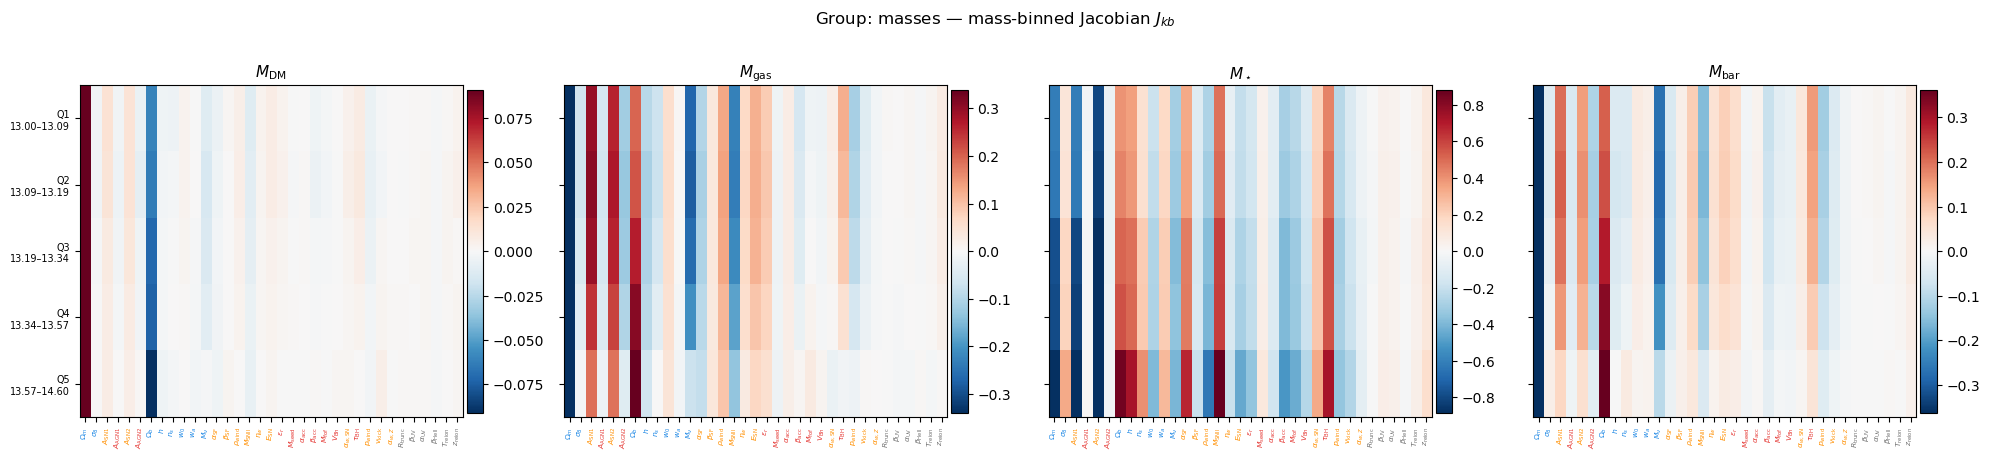

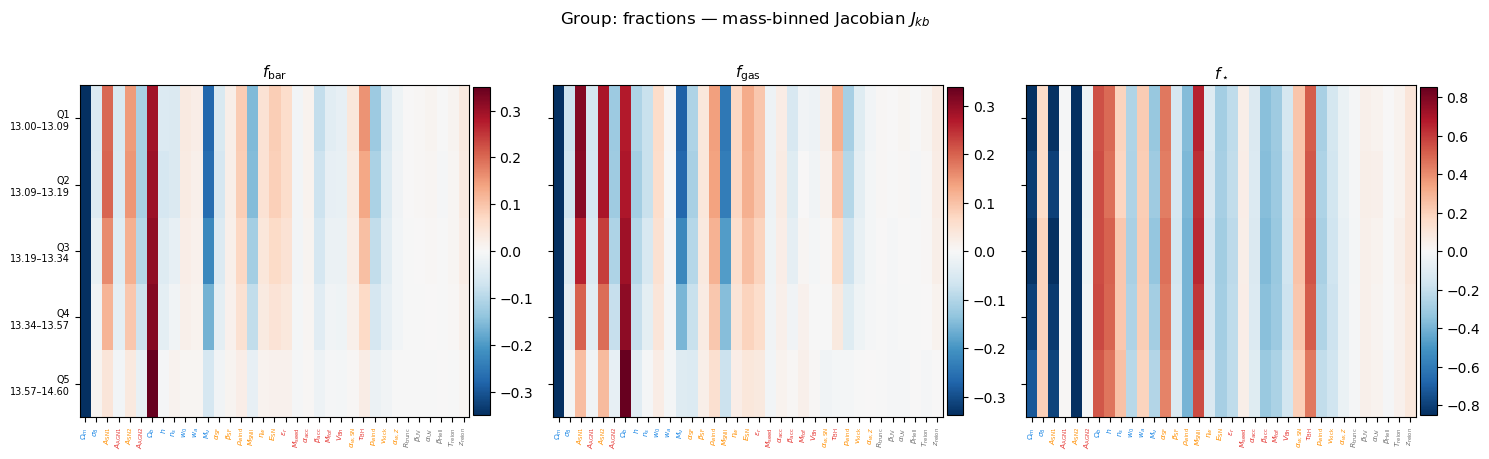

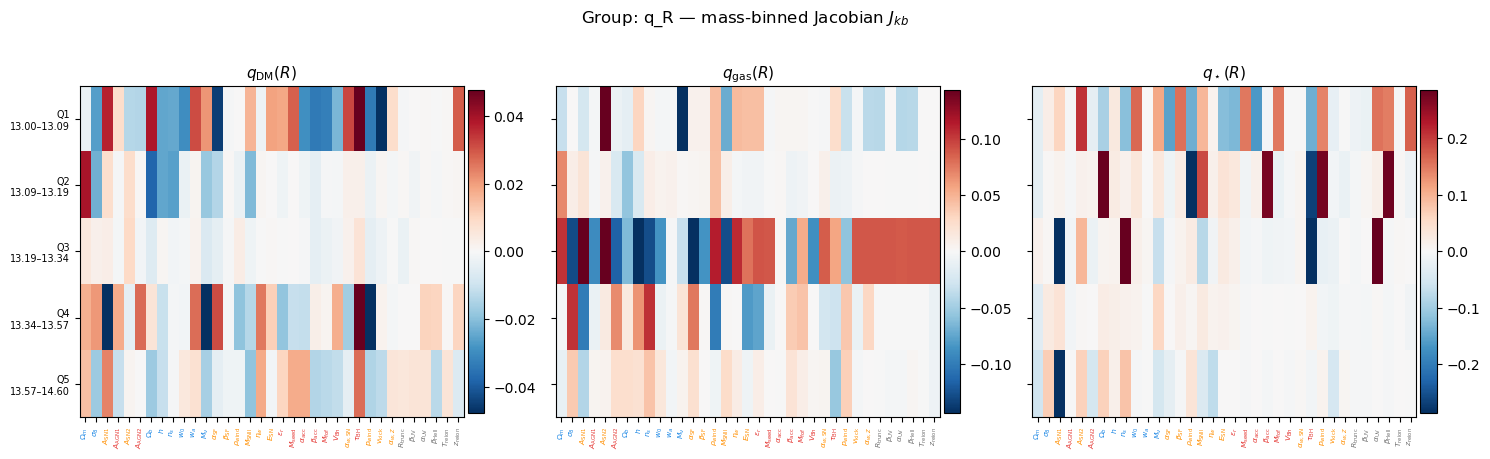

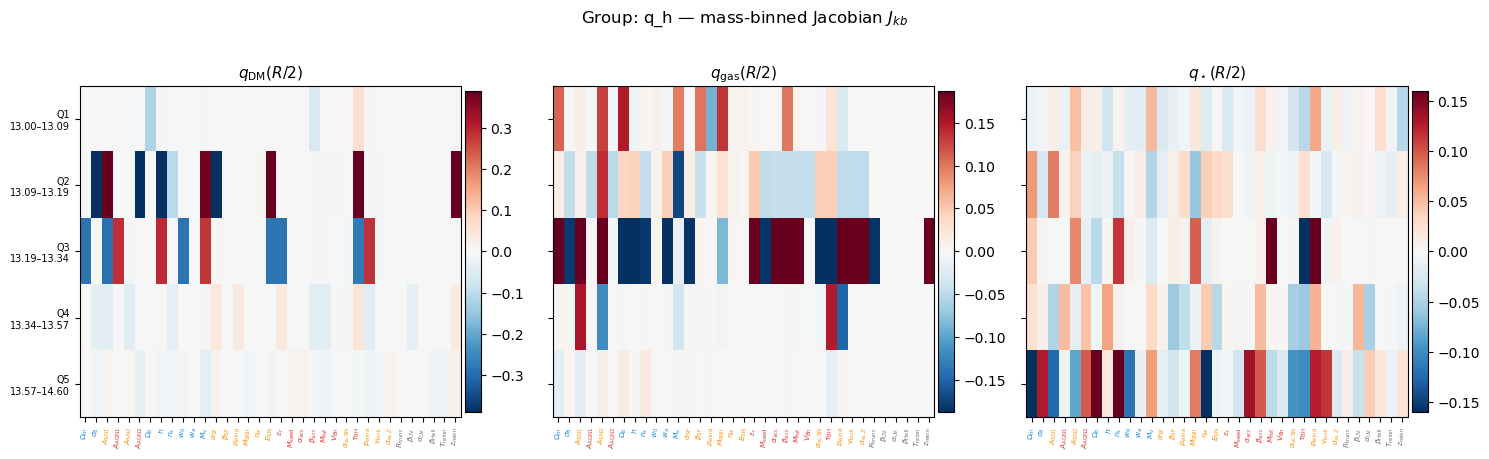

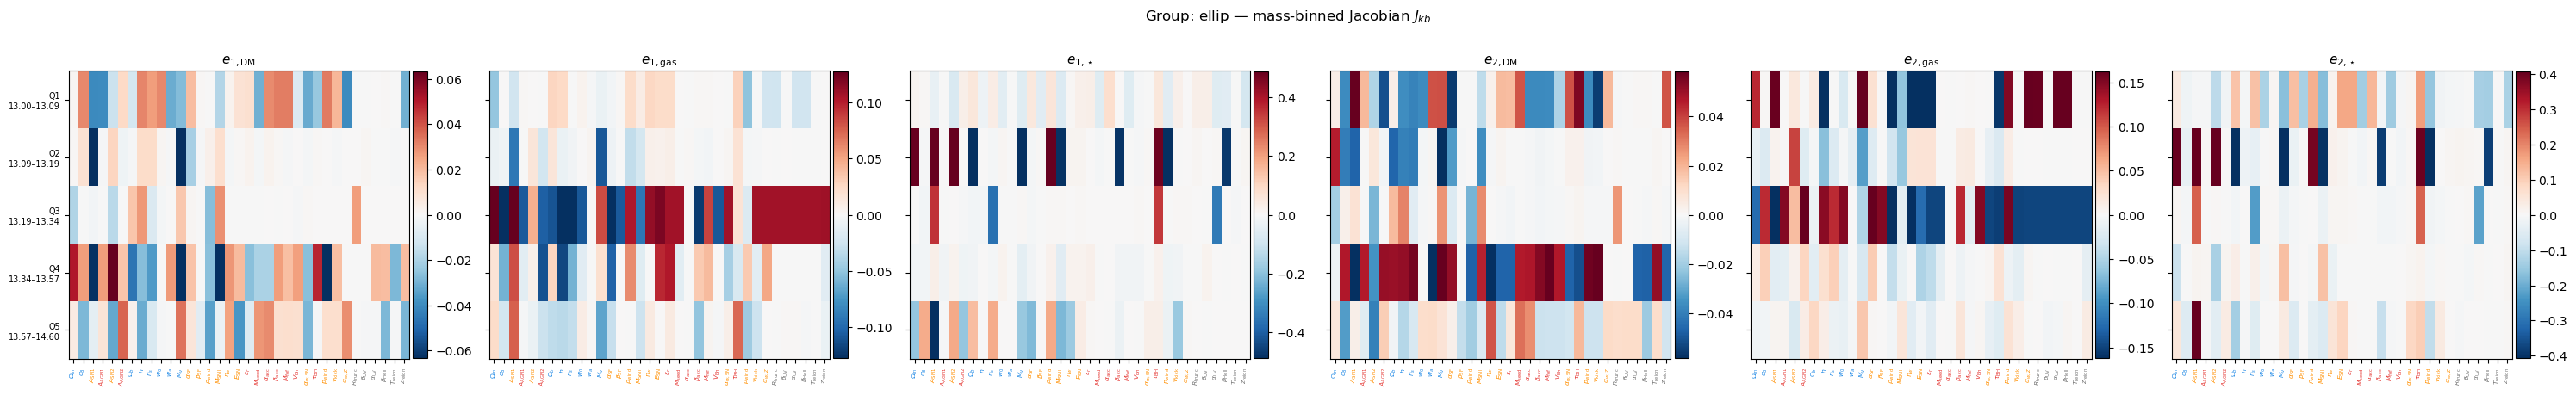

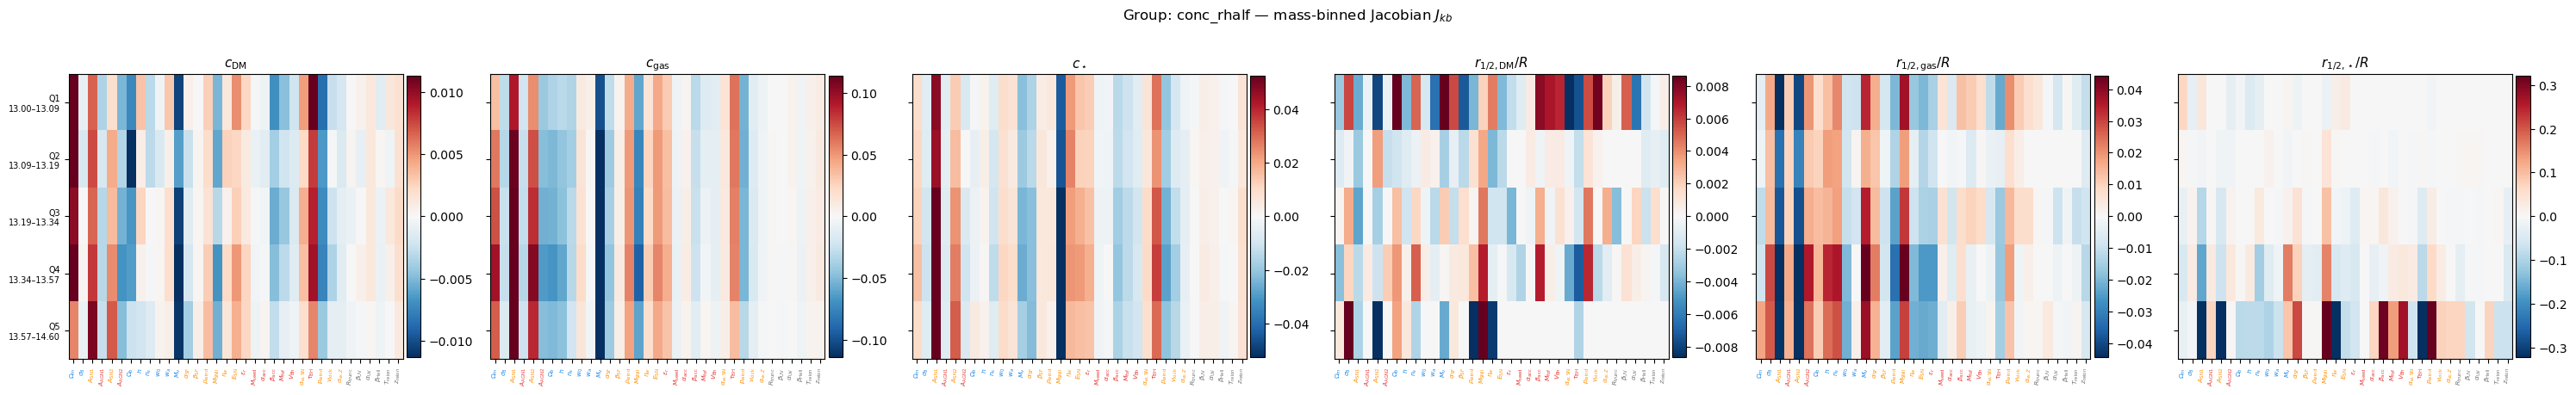

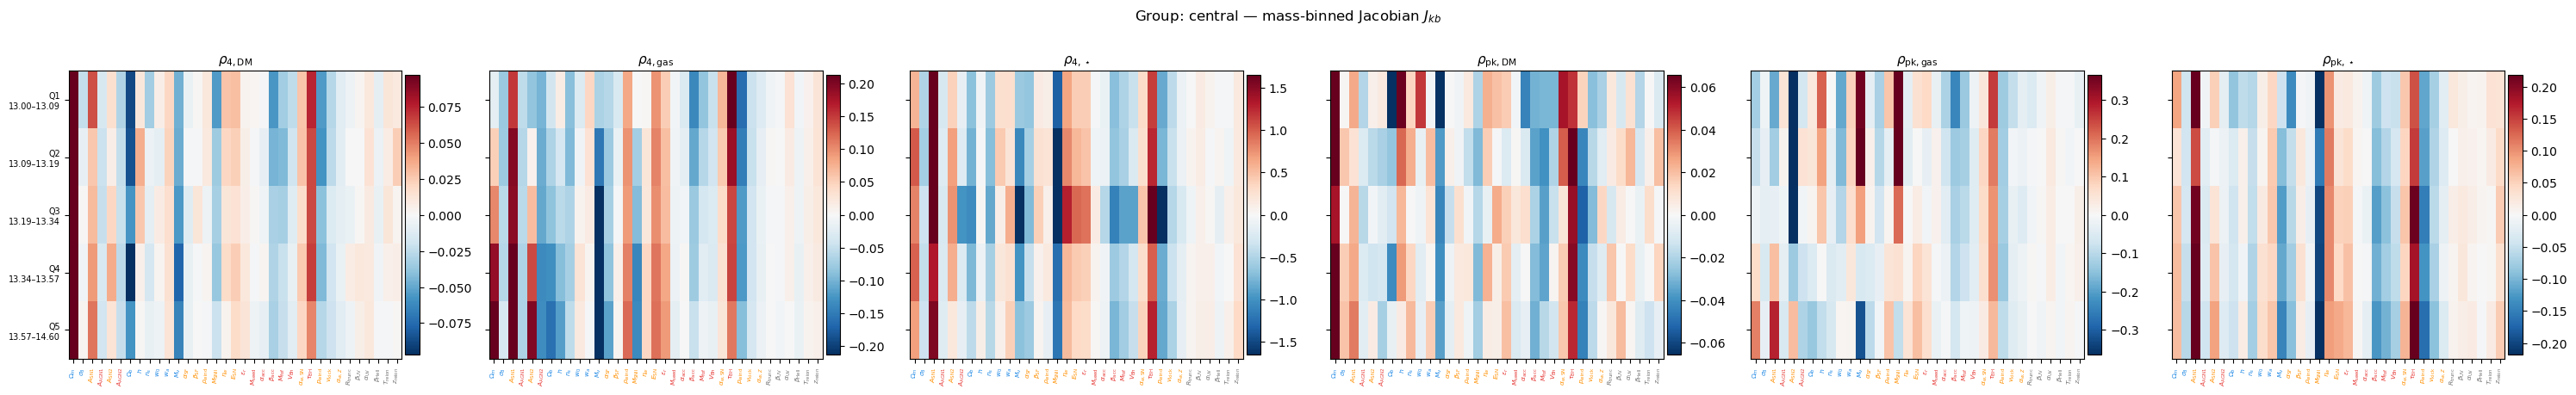

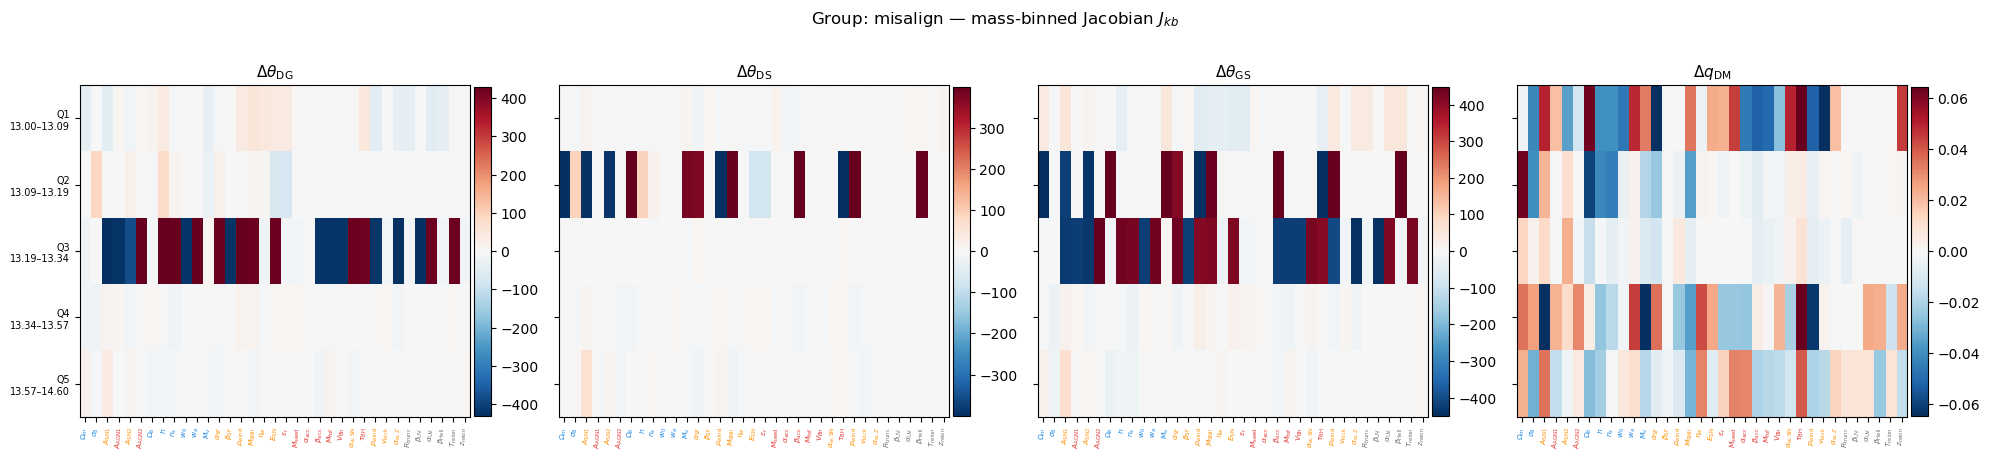

In [12]:
def plot_group_heatmap(group_name, obs_keys):
    n_obs = len(obs_keys)
    fig, axes = plt.subplots(1, n_obs, figsize=(5 * n_obs, 4.5), sharey=True)
    if n_obs == 1:
        axes = [axes]
    for ax, k in zip(axes, obs_keys):
        mat  = mean_per_bin[k]                    # (N_MBINS, 35)
        vmax = max(float(np.nanpercentile(np.abs(mat), 97)), 1e-6)
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        im   = ax.imshow(mat, aspect='auto', cmap='RdBu_r', norm=norm)
        ax.set_xticks(range(N_PARAMS))
        ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)],
                           rotation=90, fontsize=5.5)
        for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
            tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
        ax.set_yticks(range(N_MBINS))
        ax.set_yticklabels([f'Q{b+1}\n{MASS_LABELS[b]}' for b in range(N_MBINS)], fontsize=7)
        ax.set_title(KEY_LATEX[k], fontsize=11)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.01)
    fig.suptitle(f'Group: {group_name} — mass-binned Jacobian $J_{{kb}}$', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

for grp_name, grp_keys in KEY_GROUPS.items():
    plot_group_heatmap(grp_name, grp_keys)


## Observable-Stacked Heatmaps per Mass Bin

One panel per mass quintile. Rows = all 35 per-halo observables; columns = 35 CAMELS parameters.
Shared colour norm across all panels.


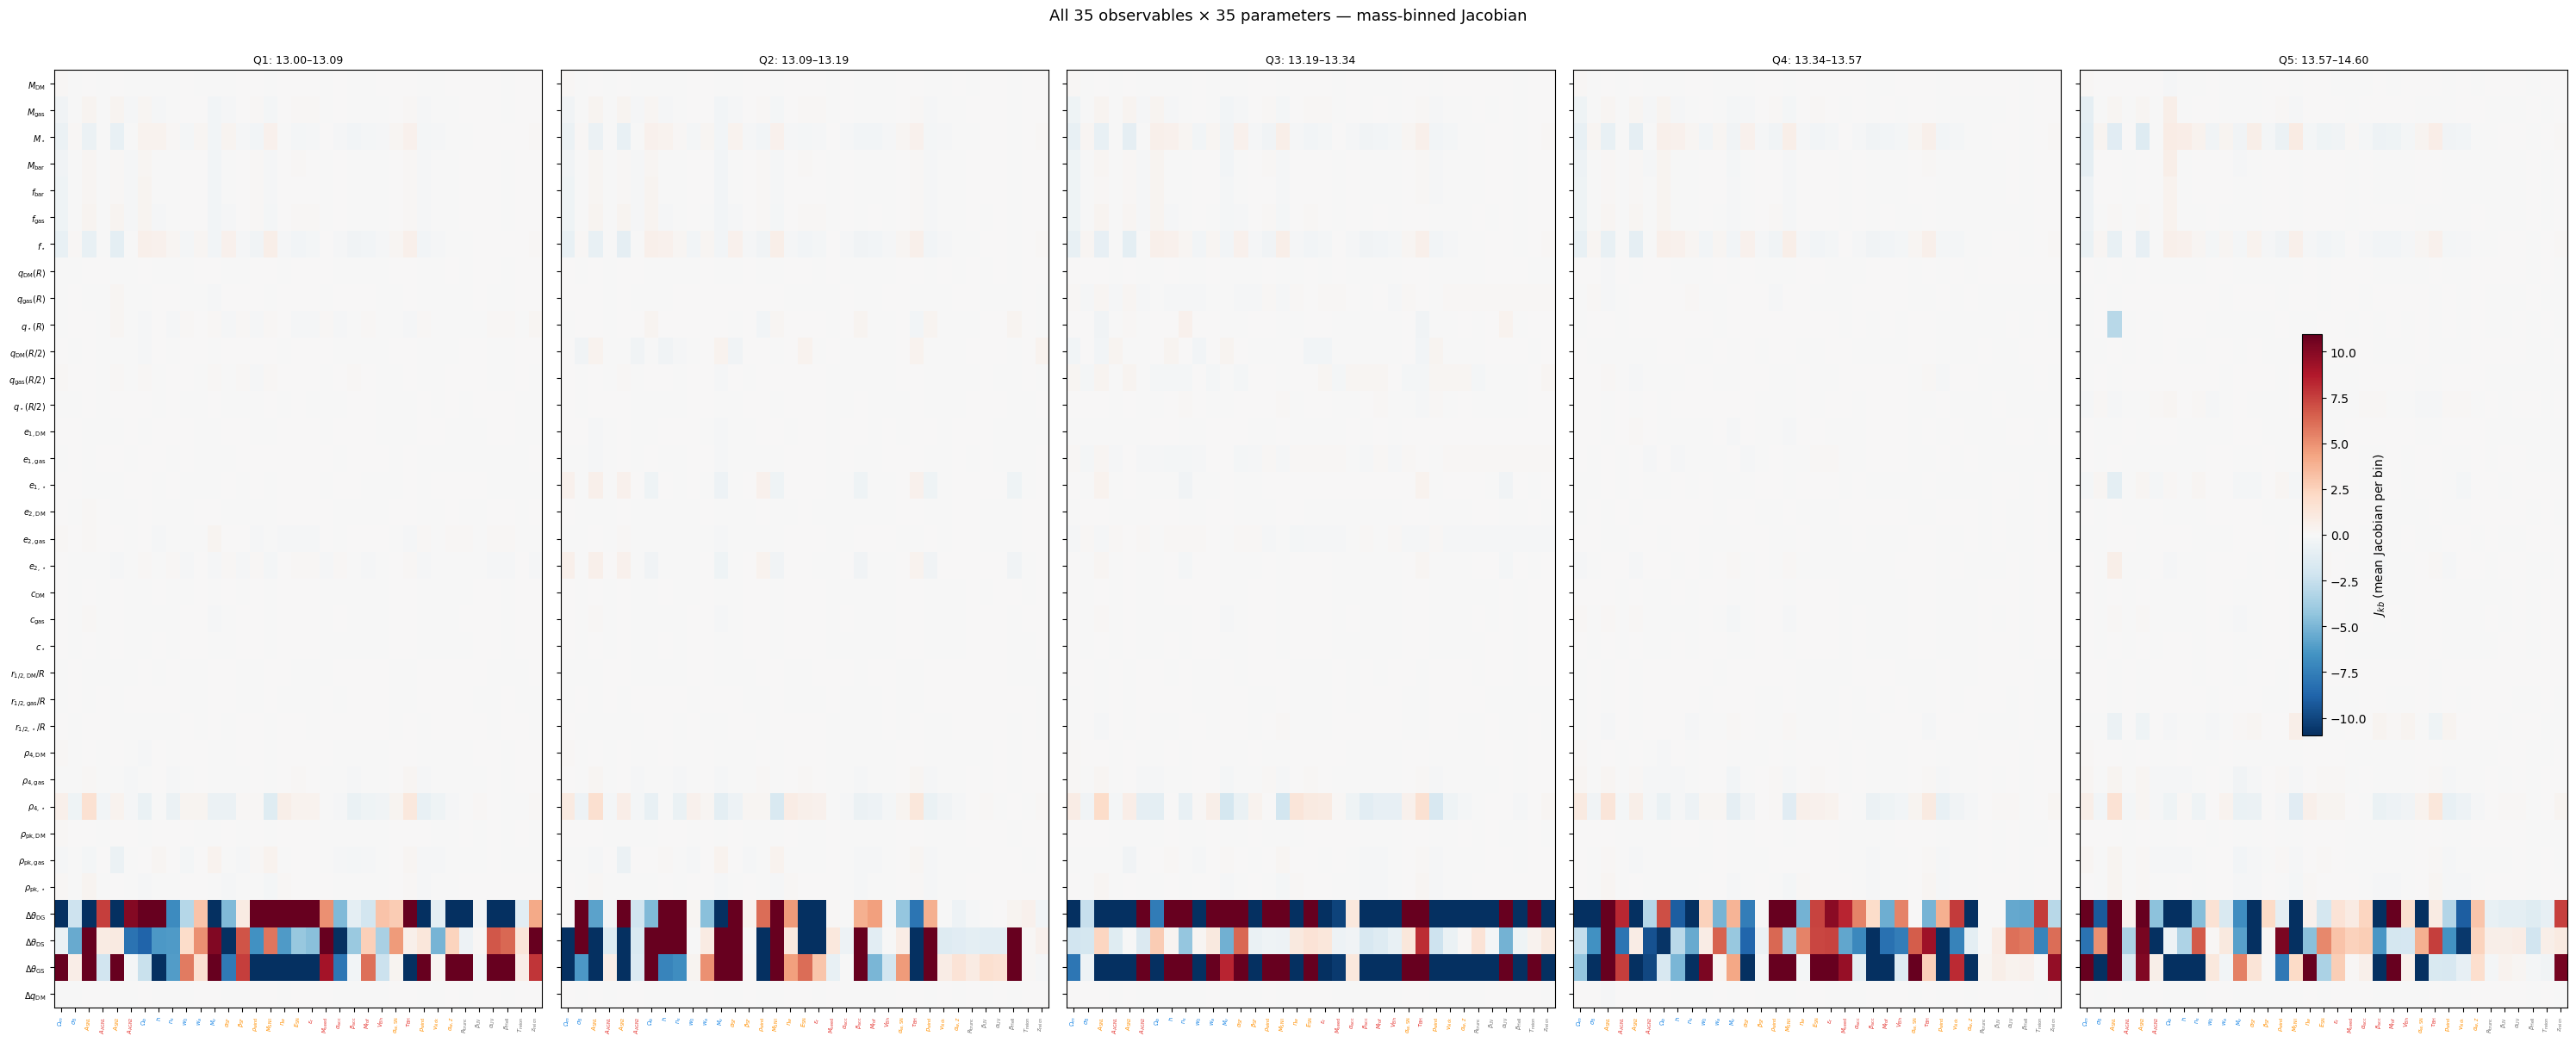

In [13]:
fig, axes = plt.subplots(1, N_MBINS, figsize=(6 * N_MBINS, 12), sharey=True)

# Shared norm across all mass bins
all_vals = np.concatenate([mean_per_bin[k] for k in PER_HALO_KEYS])
vmax_all = max(float(np.nanpercentile(np.abs(all_vals), 97)), 1e-6)
norm_all = TwoSlopeNorm(vmin=-vmax_all, vcenter=0, vmax=vmax_all)

obs_all_labels = [KEY_LATEX[k] for k in PER_HALO_KEYS]

for b, ax in enumerate(axes):
    mat = np.array([mean_per_bin[k][b] for k in PER_HALO_KEYS])  # (35, 35)
    im  = ax.imshow(mat, aspect='auto', cmap='RdBu_r', norm=norm_all)
    ax.set_xticks(range(N_PARAMS))
    ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)],
                       rotation=90, fontsize=5)
    for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
        tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
    if b == 0:
        ax.set_yticks(range(len(PER_HALO_KEYS)))
        ax.set_yticklabels(obs_all_labels, fontsize=7)
    ax.set_title(f'Q{b+1}: {MASS_LABELS[b]}', fontsize=9)

fig.colorbar(im, ax=axes, fraction=0.01, pad=0.01,
             label=r'$J_{kb}$ (mean Jacobian per bin)')
fig.suptitle('All 35 observables × 35 parameters — mass-binned Jacobian', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()


## Top Drivers per Observable vs Halo Mass

Line plot: mean Jacobian $J_{kj}(M)$ for the $N$ parameters with largest mean $|J|$.
Change `OBS_FOCUS` to explore a different observable.


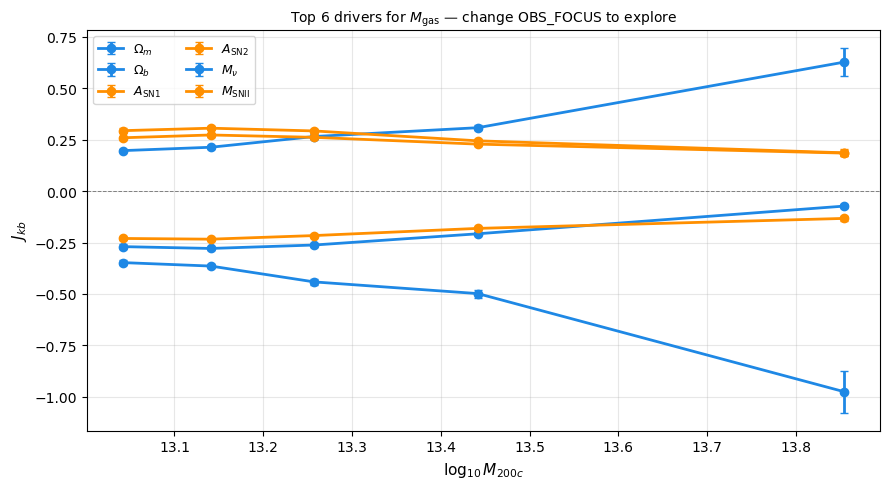

Top 3 parameter drivers per observable (mean |J| over mass bins):
  M_dm            $\Omega_m$ (0.120), $\Omega_b$ (0.075), $M_\nu$ (0.010)
  M_gas           $\Omega_m$ (0.525), $\Omega_b$ (0.323), $A_{\rm SN1}$ (0.265)
  M_star          $A_{\rm SN2}$ (1.020), $A_{\rm SN1}$ (0.819), $\Omega_m$ (0.789)
  M_bar           $\Omega_m$ (0.546), $\Omega_b$ (0.341), $M_\nu$ (0.228)
  f_bar           $\Omega_m$ (0.513), $\Omega_b$ (0.316), $M_\nu$ (0.199)
  f_gas           $\Omega_m$ (0.488), $\Omega_b$ (0.296), $A_{\rm SN1}$ (0.237)
  f_star          $A_{\rm SN2}$ (1.010), $A_{\rm SN1}$ (0.819), $\Omega_m$ (0.803)
  q_dm_R          $A_{\rm SN1}$ (0.034), $\tau_{\rm BH}$ (0.033), $p_{\rm wind}$ (0.025)
  q_gas_R         $A_{\rm SN2}$ (0.081), $A_{\rm SN1}$ (0.072), $\rho_{\rm wind}$ (0.062)
  q_star_R        $A_{\rm SN1}$ (0.708), $\tau_{\rm BH}$ (0.164), $n_s$ (0.131)
  q_dm_h          $\tau_{\rm BH}$ (0.158), $A_{\rm SN1}$ (0.148), $M_\nu$ (0.141)
  q_gas_h         $A_{\rm SN2}$ (0.142), $A_{

In [14]:
OBS_FOCUS = 'M_gas'   # ← change to explore: 'f_bar', 'conc_gas', 'q_dm_R', 'dq_dm', ...
N_DRIVERS = 6

mean_abs_k = np.abs(mean_per_bin[OBS_FOCUS]).mean(axis=0)  # mean over mass bins
top_params = np.argsort(-mean_abs_k)[:N_DRIVERS]

fig, ax = plt.subplots(figsize=(9, 5))
for j in top_params:
    m = mean_per_bin[OBS_FOCUS][:, j]
    s = se_per_bin[OBS_FOCUS][:, j]
    ax.errorbar(mass_centres, m, yerr=s, fmt='o-',
                color=GROUP_COLORS[PARAM_GROUP[j]], lw=2, ms=6, capsize=3,
                label=PRETTY.get(j, str(j)))
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_xlabel(r'$\log_{10} M_{200c}$', fontsize=11)
ax.set_ylabel(r'$J_{kb}$', fontsize=11)
ax.set_title(f'Top {N_DRIVERS} drivers for {KEY_LATEX.get(OBS_FOCUS, OBS_FOCUS)}'
             ' — change OBS_FOCUS to explore', fontsize=10)
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary: top 3 for every observable
print('Top 3 parameter drivers per observable (mean |J| over mass bins):')
for k in PER_HALO_KEYS:
    mabs = np.abs(mean_per_bin[k]).mean(axis=0)
    top3 = np.argsort(-mabs)[:3]
    desc = ', '.join(f'{PRETTY.get(j,j)} ({mabs[j]:.3f})' for j in top3)
    print(f'  {k:14s}  {desc}')


## Population Jacobians — Scaling-Relation Statistics

The FD script fit five scaling relations across all halos at $\pm\epsilon$ parameter
perturbations. The **population Jacobian** $J^{\rm pop}_{kj} = \partial S_k / \partial \tilde\theta_j$
(shape $(35,)$) measures how the population-level slope $\alpha$, intercept $\beta$,
and scatter $\sigma$ of each relation respond to each CAMELS parameter.


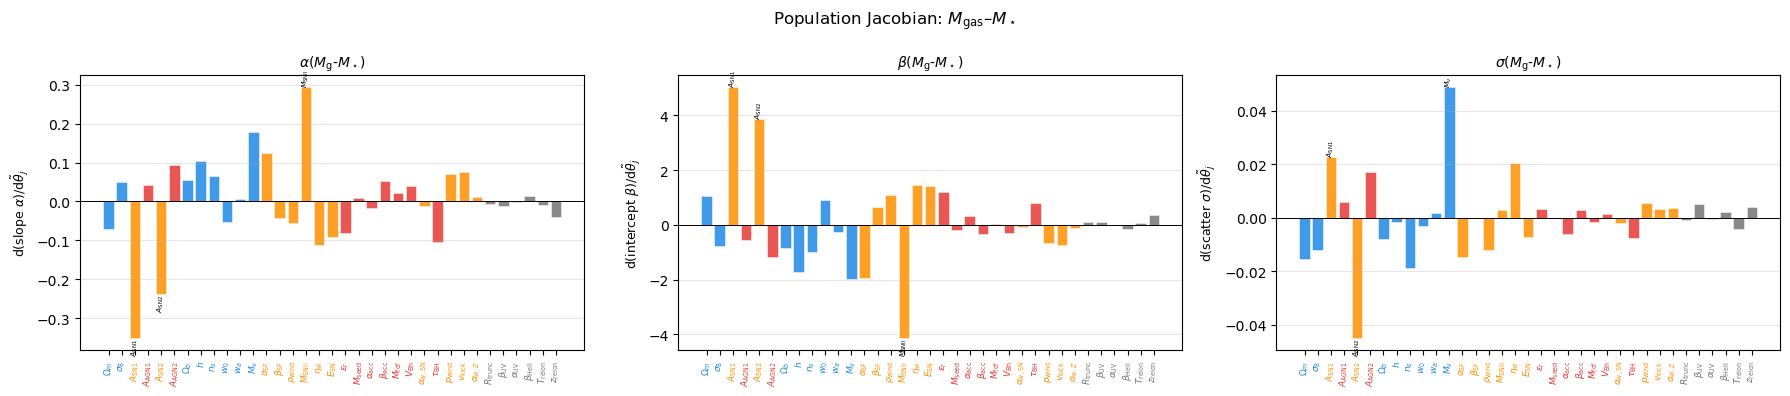

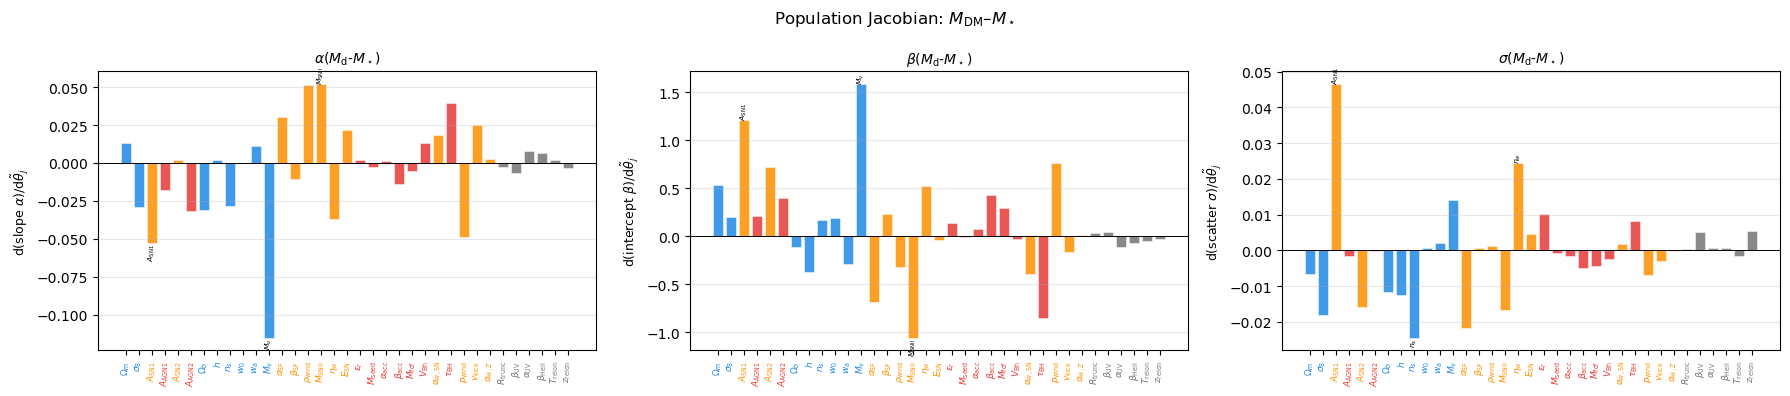

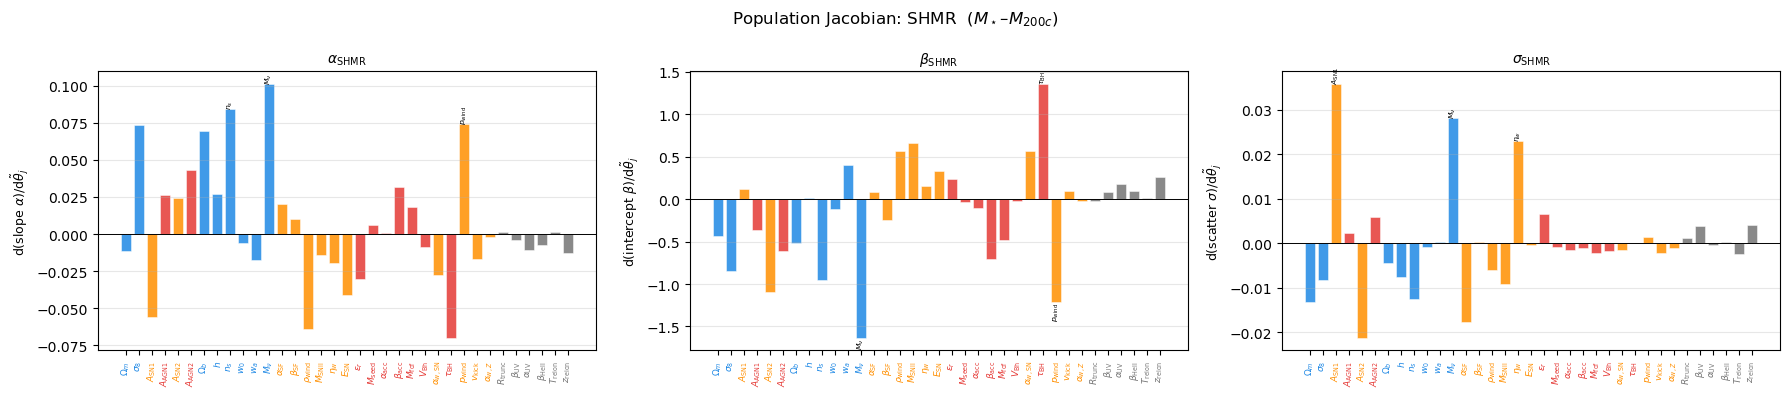

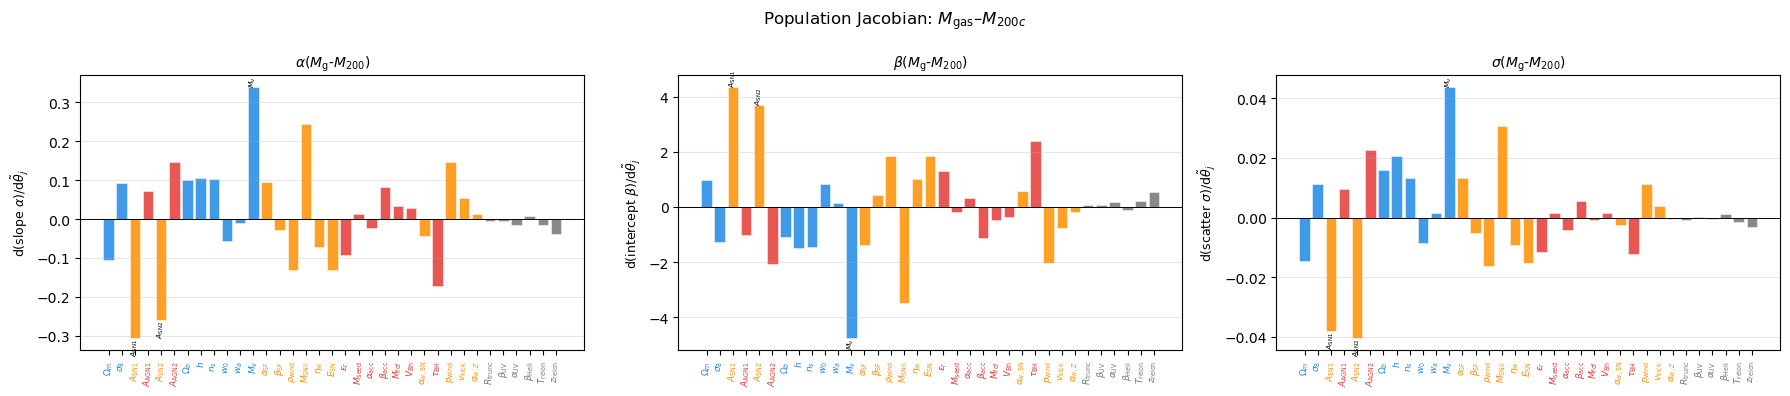

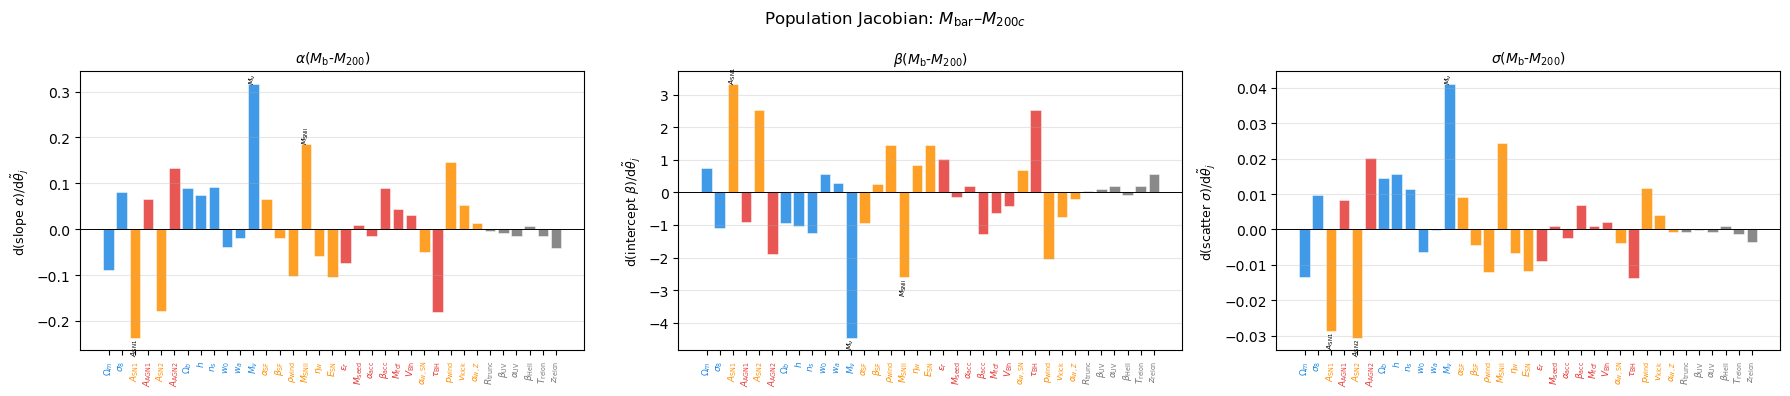

In [15]:
SCALING_RELATIONS = [
    ('MgMs',  r'$M_{\rm gas}$–$M_\star$',         ['alpha_MgMs','beta_MgMs','sigma_MgMs']),
    ('MdMs',  r'$M_{\rm DM}$–$M_\star$',           ['alpha_MdMs','beta_MdMs','sigma_MdMs']),
    ('SHMR',  r'SHMR  ($M_\star$–$M_{200c}$)',      ['alpha_SHMR', 'beta_SHMR', 'sigma_SHMR']),
    ('GasFr', r'$M_{\rm gas}$–$M_{200c}$',          ['alpha_GasFr','beta_GasFr','sigma_GasFr']),
    ('BarFr', r'$M_{\rm bar}$–$M_{200c}$',          ['alpha_BarFr','beta_BarFr','sigma_BarFr']),
]
STAT_LABELS = [r'slope $\alpha$', r'intercept $\beta$', r'scatter $\sigma$']
x = np.arange(N_PARAMS)

for rel_id, rel_latex, keys in SCALING_RELATIONS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
    fig.suptitle(f'Population Jacobian: {rel_latex}', fontsize=12)
    for ax, k, slabel in zip(axes, keys, STAT_LABELS):
        vals   = Jpop[k]
        colors_p = [GROUP_COLORS[PARAM_GROUP[j]] for j in range(N_PARAMS)]
        ax.bar(x, vals, color=colors_p, alpha=0.85, edgecolor='white', lw=0.4)
        ax.axhline(0, color='k', lw=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)],
                           rotation=90, fontsize=6.5)
        for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
            tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
        ax.set_ylabel(f'd({slabel})/d' + r'$\tilde\theta_j$', fontsize=9)
        ax.set_title(POP_LATEX[k], fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        top3 = np.argsort(-np.abs(vals))[:3]
        for jj in top3:
            ax.text(jj, vals[jj], PRETTY.get(jj, str(jj)),
                    ha='center', va='bottom' if vals[jj] >= 0 else 'top',
                    fontsize=5.5, rotation=90)
    plt.tight_layout()
    plt.show()


## Physics Validation

Four checks that the model learned real physics:

1. **Sign audit** — do the signs of median $J_{kj}$ match first-principles expectations?
2. **Chain-rule check** — does $\partial M_{\rm bar}/\partial\tilde\theta_j \approx \partial M_{\rm gas}/\partial\tilde\theta_j + \partial M_\star/\partial\tilde\theta_j$?
3. **Feedback mass-dependence** — do SN/AGN effects weaken at high mass (potential-well suppression)?
4. **Sensitivity budget** — is $M_{\rm DM}$ cosmology-dominated while $M_{\rm gas}$/$M_\star$ are feedback-dominated?


In [16]:
# Expected signs for ∂log10(F)/∂p_norm (= ∂log10(F)/∂p_nat since normalization is monotone).
# For signed observables, sign of ∂F/∂p_norm.
SIGN_PRIORS = [
    # (obs_key,      param_idx,  expected_sign (+1/-1/0),  justification)
    # --- Masses ---
    ('M_dm',    0,  +1, r'$\Omega_m\uparrow$ → deeper potential well → more DM'),
    ('M_dm',    1,  +1, r'$\sigma_8\uparrow$ → higher-peak halo → more DM'),
    ('M_gas',   6,  +1, r'$\Omega_b\uparrow$ → more baryons available'),
    ('M_star',  6,  +1, r'$\Omega_b\uparrow$ → more fuel for SF'),
    ('M_bar',   6,  +1, r'$\Omega_b\uparrow$ → more total baryons'),
    # --- Feedback on masses ---
    ('M_gas',   2,  -1, r'$A_{\rm SN1}\uparrow$ → gas ejection (prior; may be + in CAMELS)'),
    ('M_star',  2,  -1, r'$A_{\rm SN1}\uparrow$ → SN quenches star formation'),
    ('M_gas',   3,  -1, r'$A_{\rm AGN1}\uparrow$ → AGN heats/ejects gas'),
    ('M_star',  3,  -1, r'$A_{\rm AGN1}\uparrow$ → AGN quenches star formation'),
    ('M_gas',   5,  -1, r'$A_{\rm AGN2}\uparrow$ → AGN jet ejects gas'),
    # --- Baryon fractions ---
    ('f_bar',   6,  +1, r'$\Omega_b\uparrow$ → $f_b$ closer to cosmic value'),
    ('f_bar',   2,  -1, r'$A_{\rm SN1}\uparrow$ → ejects baryons → lower $f_b$'),
    ('f_bar',   3,  -1, r'$A_{\rm AGN1}\uparrow$ → ejects baryons → lower $f_b$'),
    ('f_bar',   5,  -1, r'$A_{\rm AGN2}\uparrow$ → ejects gas → lower $f_b$'),
    # --- DM insensitive to baryonic feedback ---
    ('M_dm',    2,   0, r'$A_{\rm SN1}$ should not drive DM at leading order'),
    ('M_dm',    3,   0, r'$A_{\rm AGN1}$ should not drive DM at leading order'),
    # --- Shape: feedback isotropizes ---
    ('q_gas_R', 2,  +1, r'$A_{\rm SN1}\uparrow$ → isotropises gas distribution'),
    ('q_star_R',2,  +1, r'$A_{\rm SN1}\uparrow$ → isotropises stellar distribution'),
    ('q_dm_R',  2,   0, r'$A_{\rm SN1}$ has sub-dominant effect on DM shape'),
    # --- Concentration: feedback reduces central density ---
    ('conc_gas', 2, -1, r'$A_{\rm SN1}\uparrow$ → blows out central gas'),
    ('conc_star',2, -1, r'$A_{\rm SN1}\uparrow$ → disrupts central stellar concentration'),
    # --- Baryonic spherization ---
    ('dq_dm',   2,  +1, r'$A_{\rm SN1}\uparrow$ → baryonic back-reaction makes DM rounder'),
]

J_median = {k: np.nanmedian(J_view[k], axis=0) for k in PER_HALO_KEYS}
rows = []
n_pass = n_fail = n_small = 0
for obs, pidx, exp, justif in SIGN_PRIORS:
    val   = float(J_median[obs][pidx])
    pname = PRETTY.get(pidx, str(pidx))
    if exp == 0:
        scale  = max(np.nanmax(np.abs(J_median[obs])), 1e-30)
        result = '✓ SMALL' if np.abs(val) < 0.05 * scale else '✗ LARGE'
        if '✓' in result: n_small += 1
        else:              n_fail  += 1
    else:
        result = '✓ PASS' if np.sign(val) == exp else '✗ FAIL'
        if '✓' in result: n_pass += 1
        else:              n_fail += 1
    rows.append((obs, pname, exp, f'{val:+.4f}', justif, result))

print(f'{"Observable":<16}  {"Param":<24}  {"Exp":>4}  {"Model":>8}  Result')
print('-' * 95)
for obs, pname, exp, val, just, result in rows:
    exp_str = '+' if exp == +1 else ('-' if exp == -1 else '~0')
    print(f'{obs:<16}  {pname:<24}  {exp_str:>4}  {val:>8}  {result}')
print(f'\nSummary: {n_pass} pass, {n_small} near-zero, {n_fail} fail '
      f'(pass rate: {(n_pass+n_small)/(n_pass+n_small+n_fail):.1%})')


Observable        Param                      Exp     Model  Result
-----------------------------------------------------------------------------------------------
M_dm              $\Omega_m$                   +   +0.1086  ✓ PASS
M_dm              $\sigma_8$                   +   -0.0003  ✗ FAIL
M_gas             $\Omega_b$                   +   +0.2592  ✓ PASS
M_star            $\Omega_b$                   +   +0.4696  ✓ PASS
M_bar             $\Omega_b$                   +   +0.2771  ✓ PASS
M_gas             $A_{\rm SN1}$                -   +0.2479  ✗ FAIL
M_star            $A_{\rm SN1}$                -   -0.6968  ✓ PASS
M_gas             $A_{\rm AGN1}$               -   -0.0462  ✓ PASS
M_star            $A_{\rm AGN1}$               -   -0.0060  ✓ PASS
M_gas             $A_{\rm AGN2}$               -   -0.0999  ✓ PASS
f_bar             $\Omega_b$                   +   +0.3187  ✓ PASS
f_bar             $A_{\rm SN1}$                -   +0.1380  ✗ FAIL
f_bar             $A_{\rm AGN1}$ 

Chain-rule check: ∂M_bar/∂p̃ ≈ ∂M_gas/∂p̃ + ∂M_star/∂p̃
  Median R² = 1.000
  Frac R² > 0.9: 100.0%
  Params with R² < 0.7:


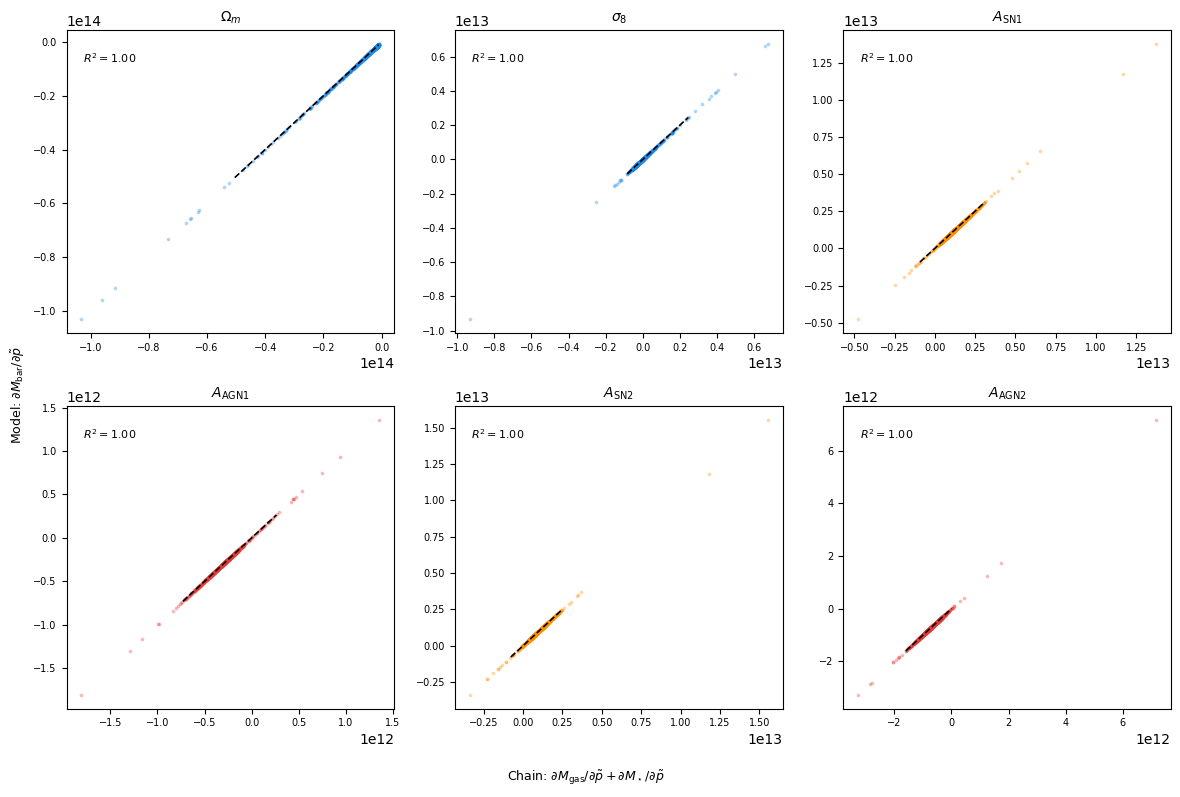

In [17]:
# Check 2: ∂M_bar/∂p ≈ ∂M_gas/∂p + ∂M_star/∂p  (use raw ∂F/∂p_norm view)
dM_bar_model = J_obs_dnorm_all['M_bar']       # (N_USE, 35) direct model output
dM_gas       = J_obs_dnorm_all['M_gas']
dM_star      = J_obs_dnorm_all['M_star']
dM_bar_chain = dM_gas + dM_star               # chain-rule prediction

resid  = dM_bar_chain - dM_bar_model
SS_res = np.nansum(resid**2, axis=0)
SS_tot = np.nansum((dM_bar_model - np.nanmean(dM_bar_model, axis=0))**2, axis=0)
r2     = 1.0 - SS_res / np.where(SS_tot > 0, SS_tot, np.nan)

print('Chain-rule check: ∂M_bar/∂p̃ ≈ ∂M_gas/∂p̃ + ∂M_star/∂p̃')
print(f'  Median R² = {np.nanmedian(r2):.3f}')
print(f'  Frac R² > 0.9: {np.nanmean(r2 > 0.9):.1%}')
print(f'  Params with R² < 0.7:')
for j in np.where(r2 < 0.7)[0]:
    print(f'    {PRETTY.get(j, j):22s}  R²={r2[j]:.3f}')

KEY_PARAMS_CR = [0, 1, 2, 3, 4, 5]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for ax_i, j in enumerate(KEY_PARAMS_CR):
    ax = axes[ax_i]
    x  = dM_bar_chain[:, j]
    y  = dM_bar_model[:, j]
    fin = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[fin], y[fin], s=3, alpha=0.25, color=GROUP_COLORS[PARAM_GROUP[j]])
    lo = min(np.nanpercentile(x[fin], 1), np.nanpercentile(y[fin], 1))
    hi = max(np.nanpercentile(x[fin], 99), np.nanpercentile(y[fin], 99))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2)
    ax.set_title(PRETTY.get(j, str(j)), fontsize=10)
    ax.text(0.05, 0.93, f'$R^2={r2[j]:.2f}$', transform=ax.transAxes, fontsize=8, va='top')
    ax.tick_params(labelsize=7)
fig.supxlabel(r'Chain: $\partial M_{\rm gas}/\partial\tilde p + \partial M_\star/\partial\tilde p$',
              fontsize=9, y=0.01)
fig.supylabel(r'Model: $\partial M_{\rm bar}/\partial\tilde p$', fontsize=9)
plt.tight_layout()
plt.savefig('./paper_figures/Mbar_chain_rule_check.pdf', bbox_inches='tight')
plt.show()


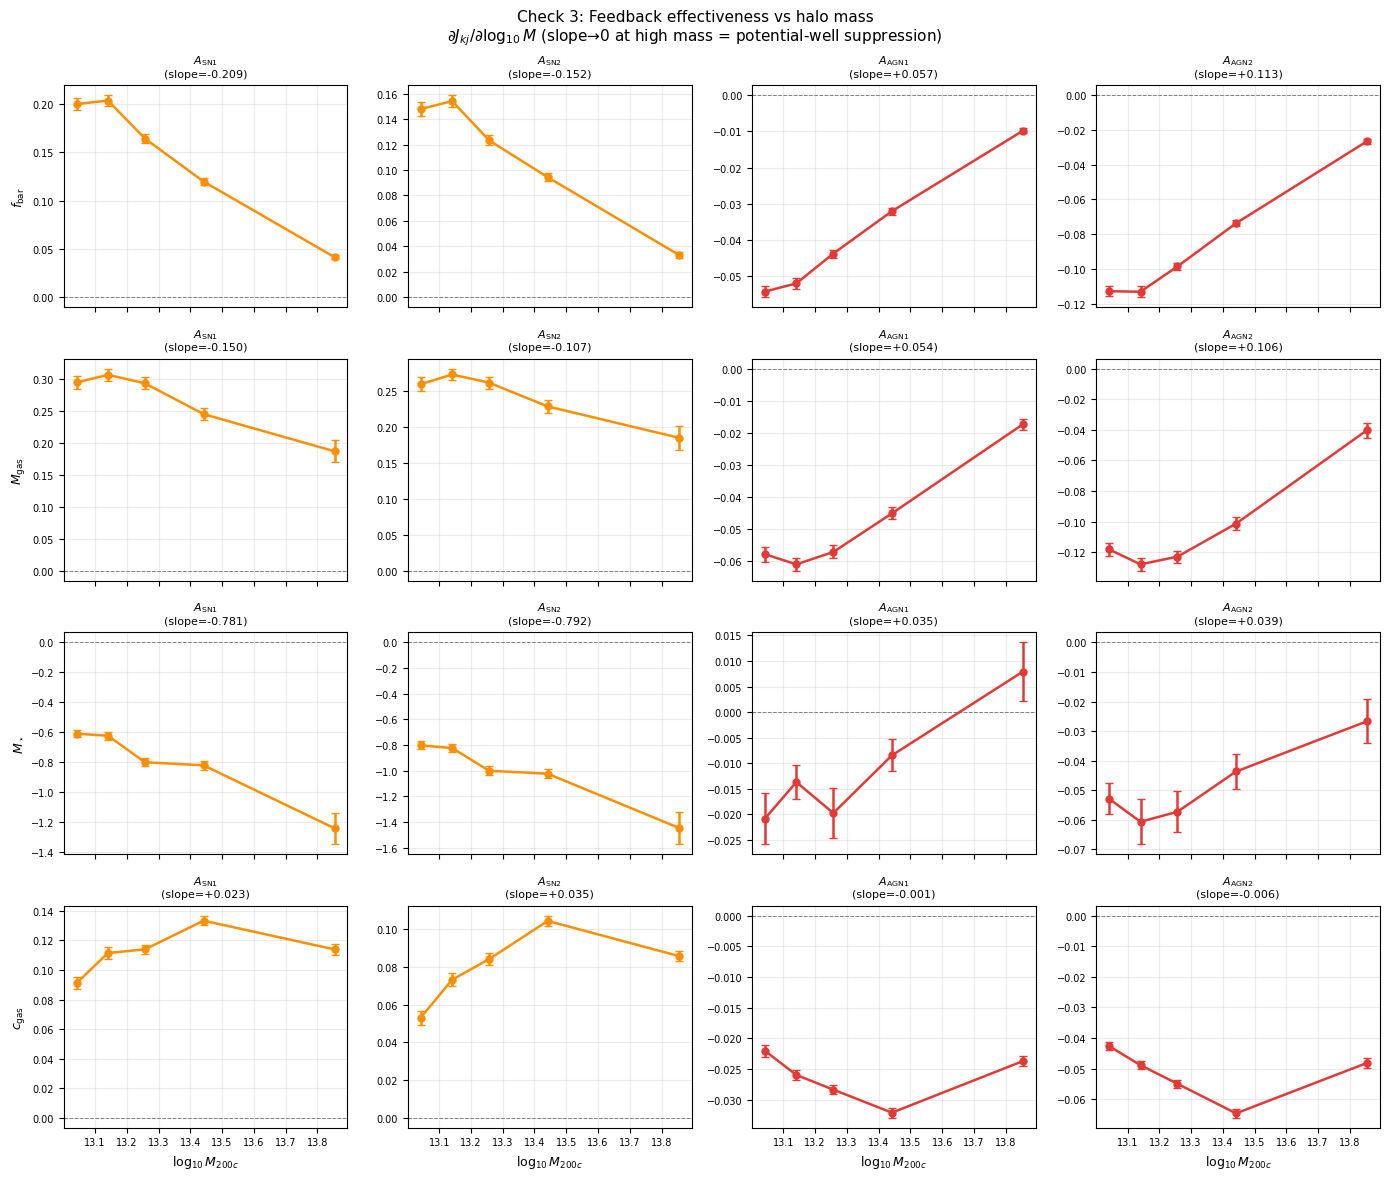

In [18]:
# Check 3: Feedback effectiveness vs halo mass
FEEDBACK_PARAMS = {
    r'$A_{\rm SN1}$':  (2, 'SN'),
    r'$A_{\rm SN2}$':  (4, 'SN'),
    r'$A_{\rm AGN1}$': (3, 'AGN'),
    r'$A_{\rm AGN2}$': (5, 'AGN'),
}
OBS_FB = ['f_bar', 'M_gas', 'M_star', 'conc_gas']

fig, axes = plt.subplots(len(OBS_FB), len(FEEDBACK_PARAMS),
                         figsize=(14, 12), sharex=True)
for row, obs in enumerate(OBS_FB):
    for col, (plabel, (pidx, ptype)) in enumerate(FEEDBACK_PARAMS.items()):
        ax = axes[row, col]
        m  = mean_per_bin[obs][:, pidx]
        s  = se_per_bin[obs][:, pidx]
        col_c = GROUP_COLORS['SN'] if ptype == 'SN' else GROUP_COLORS['AGN']
        ax.errorbar(mass_centres, m, yerr=s, fmt='o-', color=col_c, lw=1.8, ms=5, capsize=3)
        ax.axhline(0, color='gray', lw=0.7, ls='--')
        fin = np.isfinite(m)
        if fin.sum() >= 3:
            slope_fb = np.polyfit(mass_centres[fin], m[fin], 1)[0]
            ax.set_title(f'{plabel}\n(slope={slope_fb:+.3f})', fontsize=8)
        else:
            ax.set_title(plabel, fontsize=8)
        if col == 0:
            ax.set_ylabel(KEY_LATEX[obs], fontsize=9)
        if row == len(OBS_FB) - 1:
            ax.set_xlabel(r'$\log_{10}M_{200c}$', fontsize=9)
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=7)

fig.suptitle('Check 3: Feedback effectiveness vs halo mass\n'
             r'$\partial J_{kj}/\partial\log_{10}M$ (slope→0 at high mass = potential-well suppression)',
             fontsize=11)
plt.tight_layout()
plt.show()


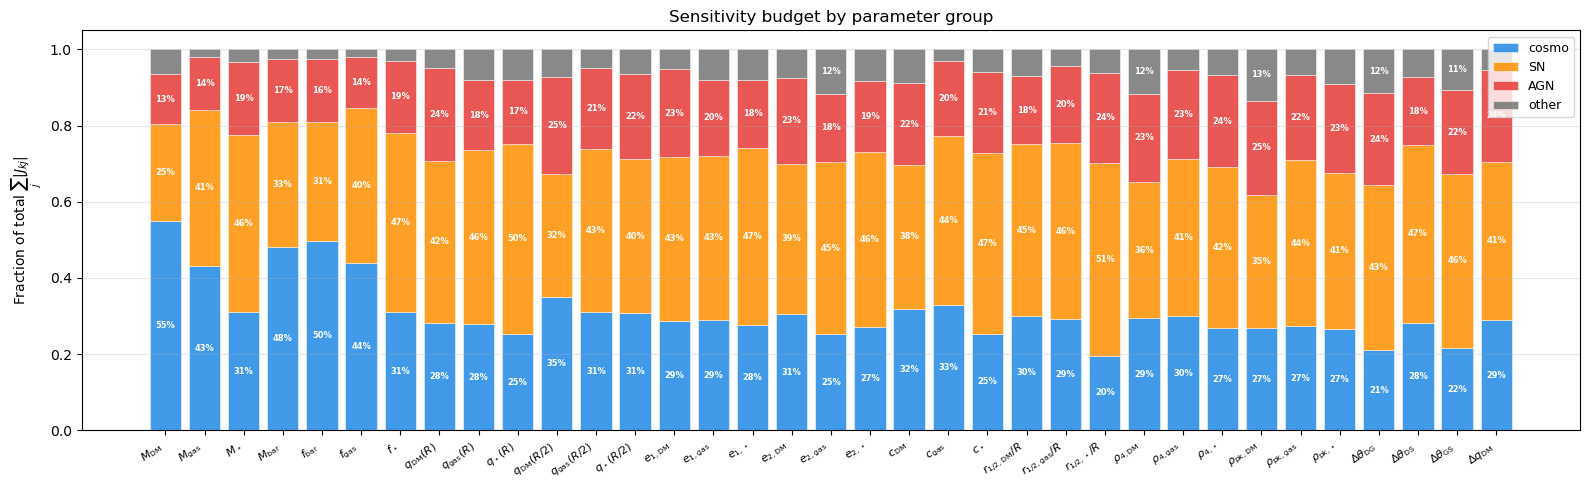


Sensitivity budget:
Observable           cosmo        SN       AGN     other
-------------------------------------------------------
M_dm                55.0%    25.5%    13.0%     6.5%
M_gas               43.2%    40.9%    14.0%     1.9%
M_star              31.0%    46.5%    19.3%     3.2%
M_bar               48.2%    32.6%    16.7%     2.5%
f_bar               49.6%    31.4%    16.4%     2.6%
f_gas               44.0%    40.5%    13.6%     1.9%
f_star              31.1%    47.1%    18.7%     3.1%
q_dm_R              28.3%    42.3%    24.4%     5.0%
q_gas_R             28.0%    45.5%    18.4%     8.1%
q_star_R            25.3%    50.0%    16.8%     7.9%
q_dm_h              34.9%    32.3%    25.4%     7.4%
q_gas_h             31.1%    42.7%    21.3%     5.0%
q_star_h            30.7%    40.5%    22.3%     6.5%
e1_dm               28.8%    43.0%    23.1%     5.1%
e1_gas              29.0%    43.1%    19.9%     8.0%
e1_star             27.7%    46.6%    17.8%     8.0%
e2_dm             

In [19]:
# Check 4: Sensitivity budget by parameter group
group_order  = ['cosmo','SN','AGN','other']
group_to_idx = {g: [j for j in range(N_PARAMS) if PARAM_GROUP[j] == g]
                for g in group_order}

frac_dict = {}
for k in PER_HALO_KEYS:
    arr_abs = np.abs(J_view[k])
    total   = float(np.nansum(arr_abs))
    if total == 0:
        continue
    frac_dict[k] = {g: float(np.nansum(arr_abs[:, group_to_idx[g]])) / total
                    for g in group_order}

fig, ax = plt.subplots(figsize=(16, 5))
obs_labels_sb = [KEY_LATEX[k] for k in PER_HALO_KEYS]
x = np.arange(len(PER_HALO_KEYS))
bottom = np.zeros(len(PER_HALO_KEYS))
for g in group_order:
    vals = np.array([frac_dict.get(k, {}).get(g, 0) for k in PER_HALO_KEYS])
    ax.bar(x, vals, bottom=bottom, color=GROUP_COLORS[g], label=g,
           alpha=0.85, edgecolor='white', lw=0.4)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 0.10:
            ax.text(xi, b + v / 2, f'{v:.0%}', ha='center', va='center',
                    fontsize=6, color='white', fontweight='bold')
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(obs_labels_sb, rotation=35, ha='right', fontsize=8)
ax.set_ylabel(r'Fraction of total $\sum_j|J_{kj}|$', fontsize=10)
ax.set_title('Sensitivity budget by parameter group', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nSensitivity budget:')
print(f'{"Observable":<16}' + ''.join(f'  {g:>8}' for g in group_order))
print('-' * 55)
for k in PER_HALO_KEYS:
    row = f'{k:<16}'
    for g in group_order:
        row += f'  {frac_dict.get(k,{}).get(g,0):>7.1%}'
    print(row)


## Full Jacobian Matrix Analysis — SVD

The SVD $\mathbf{J} = U \Sigma V^T$ decomposes the halo-mean Jacobian into orthogonal modes:

- **Right singular vectors** $V$ (rows): parameter-space combinations that drive the most observable variation.
- **Left singular vectors** $U$ (columns): observable combinations that carry the most parameter information.
- **Singular values** $\sigma_i$: mode importance.

Leading modes should correspond to recognizable physical axes (cosmology, SN feedback, AGN).


Jacobian matrix for SVD: (32, 35)  (32 observables × 35 params)


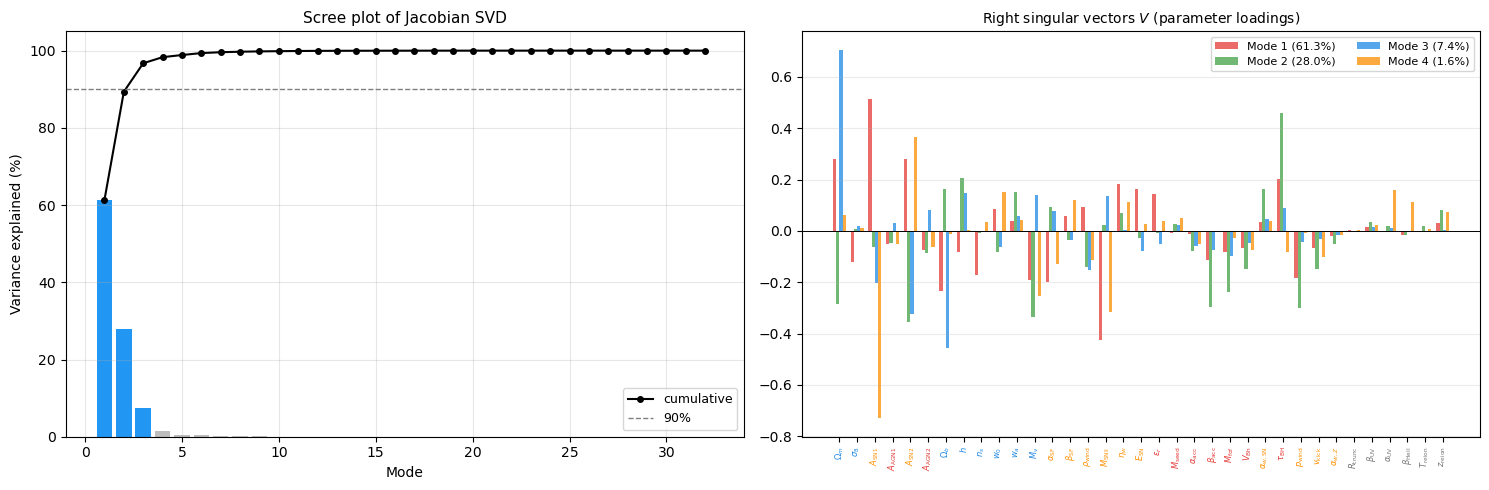


Dominant parameters per SVD mode:
  Mode 1 [61.3%]: $A_{\rm SN1}$ (+0.514), $M_{\rm SNII}$ (-0.425), $\Omega_m$ (+0.281), $A_{\rm SN2}$ (+0.280), $\Omega_b$ (-0.234)
  Mode 2 [28.0%]: $\tau_{\rm BH}$ (+0.459), $A_{\rm SN2}$ (-0.354), $M_\nu$ (-0.336), $p_{\rm wind}$ (-0.298), $\beta_{\rm acc}$ (-0.297)
  Mode 3 [7.4%]: $\Omega_m$ (+0.706), $\Omega_b$ (-0.455), $A_{\rm SN2}$ (-0.323), $A_{\rm SN1}$ (-0.204), $\rho_{\rm wind}$ (-0.153)
  Mode 4 [1.6%]: $A_{\rm SN1}$ (-0.730), $A_{\rm SN2}$ (+0.367), $M_{\rm SNII}$ (-0.316), $M_\nu$ (-0.252), $\alpha_{\rm UV}$ (+0.159)


In [20]:
EXCLUDE_SVD  = {'dtheta_dg', 'dtheta_ds', 'dtheta_gs'}
OBS_SVD_KEYS = [k for k in PER_HALO_KEYS
                if np.isfinite(J_view[k]).mean() > 0.5 and k not in EXCLUDE_SVD]
J_mean = np.array([np.nanmean(J_view[k], axis=0) for k in OBS_SVD_KEYS])  # (N_obs, 35)
print(f"Jacobian matrix for SVD: {J_mean.shape}  ({len(OBS_SVD_KEYS)} observables × {N_PARAMS} params)")

U, sv, Vt = np.linalg.svd(J_mean, full_matrices=False)
n_modes     = len(sv)
var_expl    = sv**2 / (sv**2).sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
ax = axes[0]
ax.bar(range(1, n_modes+1), var_expl*100,
       color=['#2196F3' if i < 3 else '#BDBDBD' for i in range(n_modes)])
ax.plot(range(1, n_modes+1), np.cumsum(var_expl)*100, 'k-o', ms=4, lw=1.5, label='cumulative')
ax.axhline(90, color='gray', ls='--', lw=1, label='90%')
ax.set_xlabel('Mode', fontsize=10); ax.set_ylabel('Variance explained (%)', fontsize=10)
ax.set_title('Scree plot of Jacobian SVD', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Top-4 right singular vectors (parameter loadings)
N_SHOW  = min(4, n_modes)
ax      = axes[1]
cmap_m  = ['#E53935','#43A047','#1E88E5','#FB8C00']
width   = 0.18
offsets = np.linspace(-(N_SHOW-1)*width/2, (N_SHOW-1)*width/2, N_SHOW)
for mi in range(N_SHOW):
    v = Vt[mi]
    ax.bar(np.arange(N_PARAMS) + offsets[mi], v, width=width, alpha=0.75,
           color=cmap_m[mi], label=f'Mode {mi+1} ({var_expl[mi]:.1%})')
ax.axhline(0, color='k', lw=0.7)
ax.set_xticks(range(N_PARAMS))
ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)], rotation=90, fontsize=6)
for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
    tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
ax.set_title('Right singular vectors $V$ (parameter loadings)', fontsize=10)
ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('\nDominant parameters per SVD mode:')
for mi in range(N_SHOW):
    top5 = np.argsort(-np.abs(Vt[mi]))[:5]
    desc = ', '.join(f'{PRETTY.get(j,j)} ({Vt[mi,j]:+.3f})' for j in top5)
    print(f'  Mode {mi+1} [{var_expl[mi]:.1%}]: {desc}')


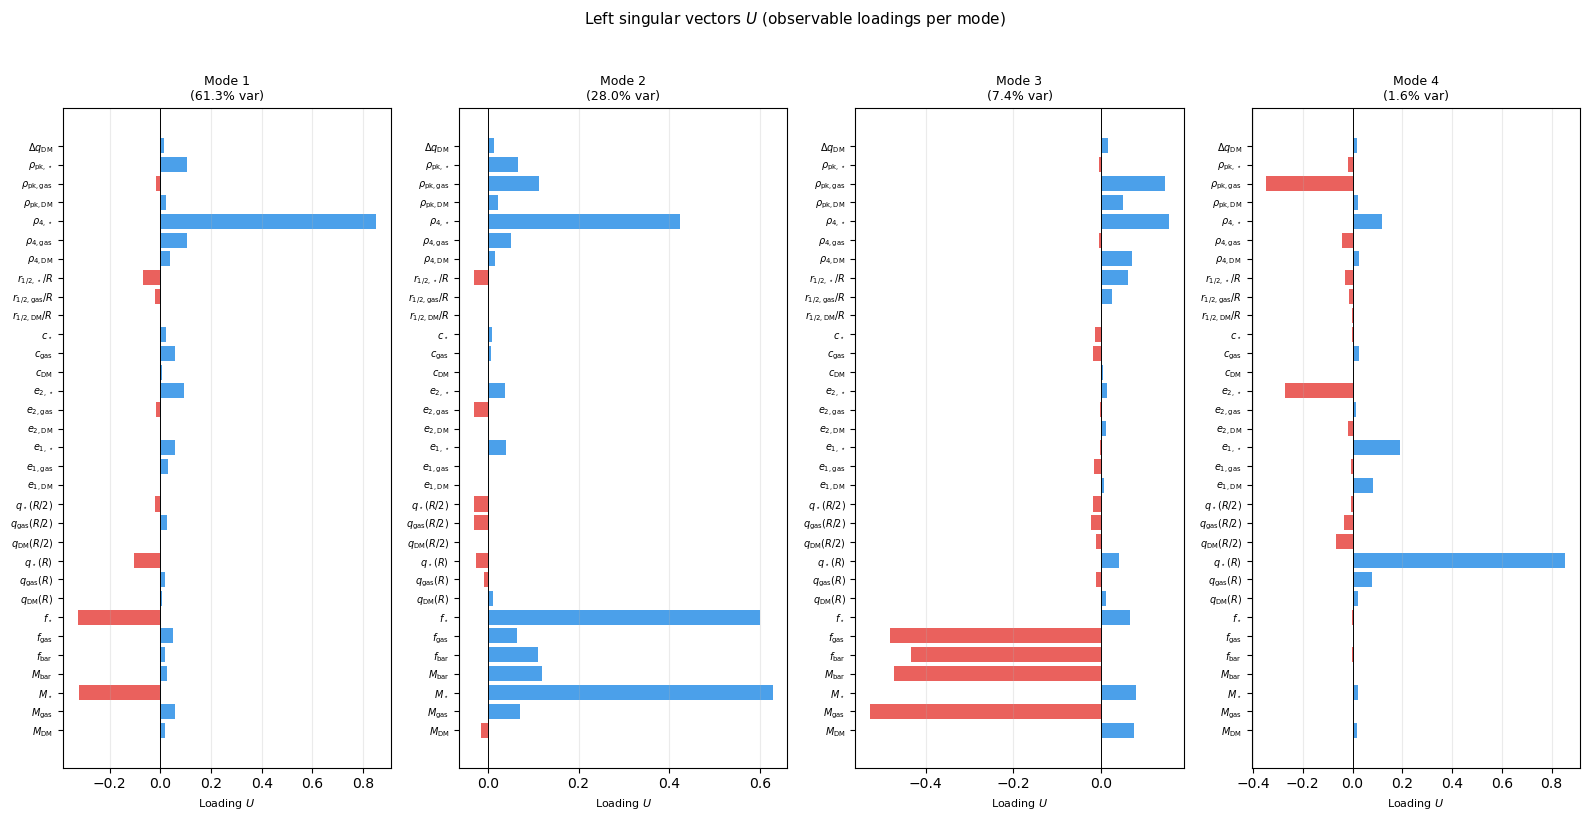

In [21]:
obs_labels_svd = [KEY_LATEX[k] for k in OBS_SVD_KEYS]
fig, axes = plt.subplots(1, N_SHOW, figsize=(4*N_SHOW, max(6, len(OBS_SVD_KEYS)*0.25)),
                          sharey=False)
for mi in range(N_SHOW):
    ax = axes[mi]
    u  = U[:, mi]
    colors_u = ['#E53935' if v < 0 else '#1E88E5' for v in u]
    ax.barh(range(len(OBS_SVD_KEYS)), u, color=colors_u, alpha=0.8)
    ax.set_yticks(range(len(OBS_SVD_KEYS)))
    ax.set_yticklabels(obs_labels_svd, fontsize=7)
    ax.axvline(0, color='k', lw=0.7)
    ax.set_title(f'Mode {mi+1}\n({var_expl[mi]:.1%} var)', fontsize=9)
    ax.set_xlabel('Loading $U$', fontsize=8)
    ax.grid(axis='x', alpha=0.25)
fig.suptitle('Left singular vectors $U$ (observable loadings per mode)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


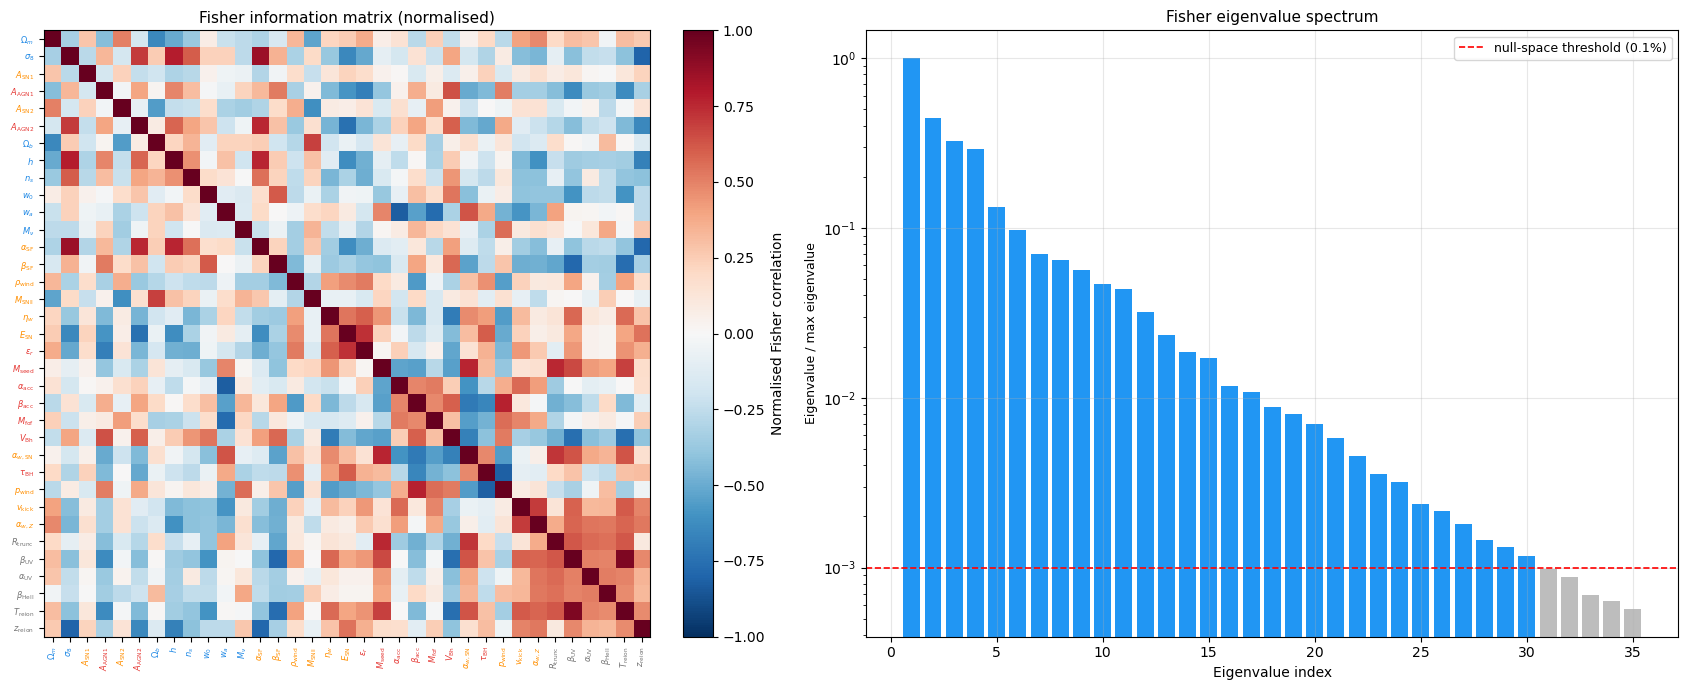

30/35 parameters above null-space threshold (detectable)
Null-space dimension: 5

Top-10 most detectable parameters:
  $A_{\rm SN1}$           detect=1.0000  group=SN
  $M_\nu$                 detect=0.1813  group=cosmo
  $\tau_{\rm BH}$         detect=0.1667  group=AGN
  $A_{\rm SN2}$           detect=0.1272  group=SN
  $\Omega_m$              detect=0.1246  group=cosmo
  $M_{\rm SNII}$          detect=0.1234  group=SN
  $p_{\rm wind}$          detect=0.1194  group=SN
  $\Omega_b$              detect=0.0996  group=cosmo
  $h$                     detect=0.0918  group=cosmo
  $E_{\rm SN}$            detect=0.0802  group=SN


In [22]:
# Noise floor: halo-to-halo scatter of fiducial observable
sigma_k = {}
for k in OBS_SVD_KEYS:
    v = F_fid_arr[k]
    if k in LOG_POS_KEYS:
        fin = v[(v > 0) & np.isfinite(v)]
        sigma_k[k] = float(np.std(np.log10(fin))) if len(fin) >= 10 else np.nan
    else:
        fin = v[np.isfinite(v)]
        sigma_k[k] = float(np.std(fin)) if len(fin) >= 10 else np.nan

# Fisher: F_ij = Σ_h Σ_k (J_hki J_hkj) / σ_k²
J_tensor  = np.stack([J_view[k] for k in OBS_SVD_KEYS], axis=1)   # (N_USE, N_obs, 35)
inv_var   = np.array([1/sigma_k[k]**2 if np.isfinite(sigma_k.get(k, np.nan)) else 0.0
                      for k in OBS_SVD_KEYS])
J_clean   = np.nan_to_num(J_tensor, nan=0.0)
J_wt      = J_clean * np.sqrt(inv_var)[None, :, None]
F_fisher  = np.einsum('hki,hkj->ij', J_wt, J_wt)   # (35, 35)

diag_sqrt = np.sqrt(np.maximum(np.diag(F_fisher), 0))
diag_sqrt = np.where(diag_sqrt > 0, diag_sqrt, 1.0)
F_norm    = F_fisher / np.outer(diag_sqrt, diag_sqrt)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax = axes[0]
im = ax.imshow(F_norm, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Normalised Fisher correlation')
labels_p = [PRETTY.get(j, str(j)) for j in range(N_PARAMS)]
ax.set_xticks(range(N_PARAMS)); ax.set_yticks(range(N_PARAMS))
ax.set_xticklabels(labels_p, rotation=90, fontsize=6)
ax.set_yticklabels(labels_p, fontsize=6)
for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
    tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
for tick, j in zip(ax.get_yticklabels(), range(N_PARAMS)):
    tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
ax.set_title('Fisher information matrix (normalised)', fontsize=11)

eigvals, _ = np.linalg.eigh(F_fisher)
eigvals    = eigvals[::-1]
ax2 = axes[1]
ax2.bar(range(1, N_PARAMS+1), eigvals/eigvals[0],
        color=['#2196F3' if v > 1e-3 else '#BDBDBD' for v in eigvals/eigvals[0]])
ax2.set_yscale('log')
ax2.axhline(1e-3, color='red', ls='--', lw=1.2, label='null-space threshold (0.1%)')
ax2.set_xlabel('Eigenvalue index', fontsize=10)
ax2.set_ylabel('Eigenvalue / max eigenvalue', fontsize=9)
ax2.set_title('Fisher eigenvalue spectrum', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_det = int((eigvals/eigvals[0] > 1e-3).sum())
print(f'{n_det}/{N_PARAMS} parameters above null-space threshold (detectable)')
print(f'Null-space dimension: {N_PARAMS - n_det}')

# Per-param detectability rank
detectability = np.diag(F_fisher) / np.diag(F_fisher).max()
rank_det = np.argsort(-detectability)
print('\nTop-10 most detectable parameters:')
for i in rank_det[:10]:
    print(f'  {PRETTY.get(i,i):22s}  detect={detectability[i]:.4f}  group={PARAM_GROUP[i]}')


## Observable–Observable Jacobian Correlations

The **Jacobian cosine similarity** $\rho_{ab} = \mathbf{j}_a \cdot \mathbf{j}_b / (|\mathbf{j}_a||\mathbf{j}_b|)$
measures how similarly two observables respond to parameter variations.
Computed per halo from the raw $\partial F / \partial \tilde\theta$ view (valid for signed observables too).


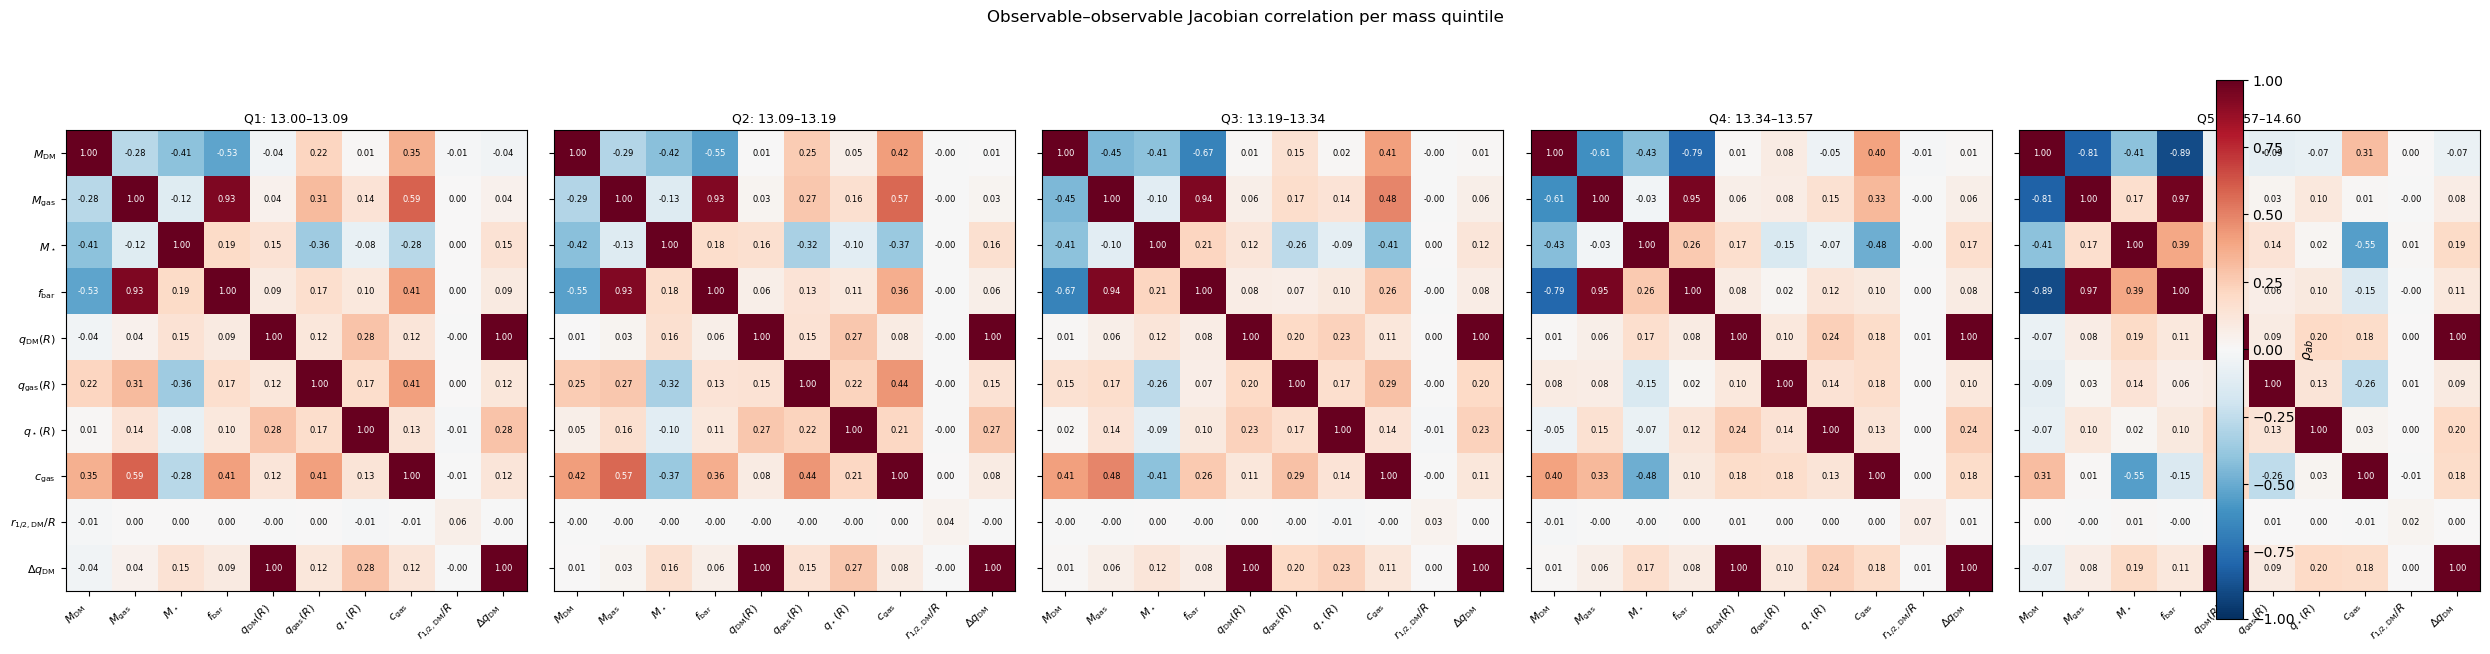

Overall mean Jacobian correlations (select pairs):
  M_gas        ↔ M_star        ρ = -0.043
  M_gas        ↔ f_bar         ρ = +0.942
  M_dm         ↔ M_gas         ρ = -0.488
  q_gas_R      ↔ q_star_R      ρ = +0.167
  conc_gas     ↔ rhalf_dm      ρ = -0.002


In [23]:
OBS_CORR_KEYS = [
    'M_dm','M_gas','M_star','f_bar',
    'q_dm_R','q_gas_R','q_star_R',
    'conc_gas','rhalf_dm','dq_dm',
]

J_corr_raw   = np.stack([J_obs_dnorm_all[k] for k in OBS_CORR_KEYS], axis=1)   # (N_USE, N_obs, 35)
J_corr_clean = np.nan_to_num(J_corr_raw, nan=0.0)
norms        = np.linalg.norm(J_corr_clean, axis=2, keepdims=True)
J_corr_norm  = np.where(norms > 0, J_corr_clean / norms, 0.0)
rho_corr     = np.einsum('haj,hbj->hab', J_corr_norm, J_corr_norm)   # (N_USE, N_obs, N_obs)

rho_by_bin = np.stack(
    [rho_corr[bin_idx == b].mean(axis=0) for b in range(N_MBINS)], axis=0
)   # (N_MBINS, N_obs, N_obs)

obs_corr_labels = [KEY_LATEX[k] for k in OBS_CORR_KEYS]
fig, axes = plt.subplots(1, N_MBINS, figsize=(5 * N_MBINS, 7))
for b, ax in enumerate(axes):
    mat = rho_by_bin[b]
    im  = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(OBS_CORR_KEYS)))
    ax.set_yticks(range(len(OBS_CORR_KEYS)))
    ax.set_xticklabels(obs_corr_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(obs_corr_labels if b == 0 else [], fontsize=8)
    ax.set_title(f'Q{b+1}: {MASS_LABELS[b]}', fontsize=9)
    for i in range(len(OBS_CORR_KEYS)):
        for j in range(len(OBS_CORR_KEYS)):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(mat[i,j]) > 0.5 else 'black')

fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label=r'$\rho_{ab}$')
fig.suptitle('Observable–observable Jacobian correlation per mass quintile', fontsize=12)
plt.tight_layout()
plt.show()

# Summary: print overall mean correlation
rho_mean = rho_corr.mean(axis=0)
print('Overall mean Jacobian correlations (select pairs):')
pairs = [('M_gas','M_star'),('M_gas','f_bar'),('M_dm','M_gas'),
         ('q_gas_R','q_star_R'),('conc_gas','rhalf_dm')]
oi = {k: i for i, k in enumerate(OBS_CORR_KEYS)}
for ka, kb in pairs:
    if ka in oi and kb in oi:
        print(f'  {ka:12s} ↔ {kb:12s}  ρ = {rho_mean[oi[ka],oi[kb]]:+.3f}')
